# Thesis Figures

This notebook contains the code used to generate figures for the thesis manuscript. Figures produced here are intended to be inserted into LaTeX, so plots should not include titles; the title and interpretation belong in the LaTeX caption.

General conventions used in this notebook:

- Axes are labelled with non-dimensional quantities, such as $x/D$ and $y/D$.
- Figures are saved at high resolution in `code/figures/thesis/`.
- The original experimental data files are only read, never modified.
- Each figure should be generated by a reusable function, so later thesis figures can be reproduced with different runs or parameters.


In [2]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

# Keep matplotlib text compatible with the LaTeX notation used in the thesis.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

# Resolve paths robustly whether the notebook is run from the repository root
# or directly from the code/ directory in VS Code.
CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == "code":
    CODE_DIR = CURRENT_DIR
elif (CURRENT_DIR / "code").exists():
    CODE_DIR = CURRENT_DIR / "code"
else:
    CODE_DIR = Path(r"X:/TFG_datos/code")

DATA_DIR = CODE_DIR / "data"
FIGURE_DIR = CODE_DIR / "figures" / "thesis"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR, FIGURE_DIR


(WindowsPath('x:/TFG_datos/code/data'),
 WindowsPath('x:/TFG_datos/code/figures/thesis'))

## Instantaneous PIV Velocity Field

The first figure shows one instantaneous velocity field from a selected PIV run. The background color represents the non-dimensional velocity magnitude,

$$
|\mathbf{U}| = \sqrt{U^2 + V^2},
$$

while the arrows show the local in-plane velocity direction. The full instantaneous components $U$ and $V$ are used here, not the fluctuating components $u$ and $v$.


In [2]:
def load_instantaneous_velocity_snapshot(run_id: int, snapshot_idx: int):
    """Load one full instantaneous velocity snapshot from a raw PIV .mat file.

    The raw files are large, so this function reads only the selected time index
    from U and V instead of loading the complete arrays into memory.
    """
    mat_path = DATA_DIR / f"Run{run_id}_PIV.mat"

    # Open the HDF5-backed MATLAB file in read-only mode.
    with h5py.File(mat_path, "r") as f:
        n_snapshots = f["U"].shape[0]

        # Validate the requested time index before reading data.
        if not 0 <= snapshot_idx < n_snapshots:
            raise IndexError(
                f"snapshot_idx={snapshot_idx} is outside the valid range "
                f"[0, {n_snapshots - 1}] for Run {run_id}."
            )

        # Spatial coordinates are lightweight and shared by all snapshots.
        X = f["X"][:]
        Y = f["Y"][:]

        # Read only one instantaneous field, using U,V rather than u,v.
        U = f["U"][snapshot_idx, :, :]
        V = f["V"][snapshot_idx, :, :]

    return X, Y, U, V


def plot_velocity_snapshot_quiver(
    X,
    Y,
    U,
    V,
    output_stem: str,
    quiver_step: int = 5,
    quiver_scale: float = 20,
    cmap: str = "RdBu_r",
):
    """Plot velocity magnitude with a quiver overlay and save it for LaTeX.

    No title is added because the thesis caption will provide the title.
    """
    # Magnitude of the non-dimensional instantaneous velocity field.
    speed = np.sqrt(U**2 + V**2)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Filled contours match the style used in the existing velocity-field plots.
    pcm = ax.pcolormesh(X, Y, speed, cmap=cmap, shading="auto")
    cbar = plt.colorbar(pcm, ax=ax)
    cbar.set_label(r"$|\mathbf{U}|/U_\infty$", fontsize=12)

    # Downsample arrows so the quiver field remains readable in the thesis.
    q = ax.quiver(
        X[::quiver_step, ::quiver_step],
        Y[::quiver_step, ::quiver_step],
        U[::quiver_step, ::quiver_step],
        V[::quiver_step, ::quiver_step],
        scale=quiver_scale,
        color="k",
        alpha=0.7,
    )

    # Labels only: the LaTeX caption will carry the figure title.
    ax.set_xlabel(r"$x/D$")
    ax.set_ylabel(r"$y/D$")
    ax.set_aspect("equal")
    plt.tight_layout()

    # Save both PNG and PDF versions for flexible thesis inclusion.
    png_path = FIGURE_DIR / f"{output_stem}.png"
    pdf_path = FIGURE_DIR / f"{output_stem}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()
    return png_path, pdf_path


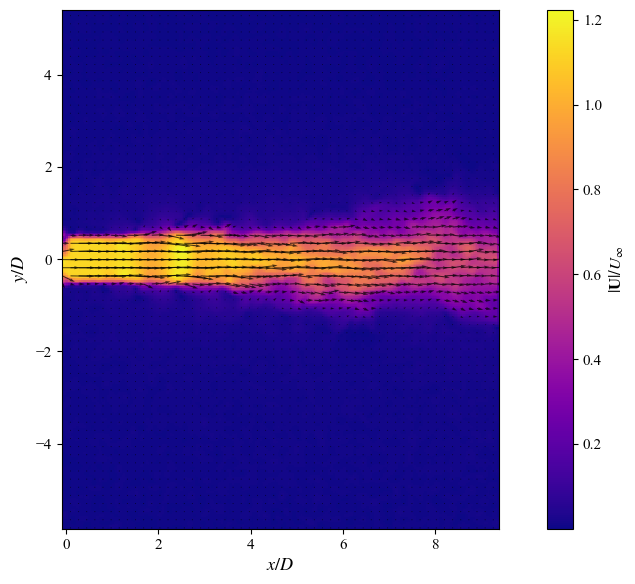

Saved PNG: F:\TFG_datos\code\figures\thesis\run1_snapshot1_velocity_quiver.png
Saved PDF: F:\TFG_datos\code\figures\thesis\run1_snapshot1_velocity_quiver.pdf


In [3]:
# Figure 1: instantaneous full velocity field from one forced run.
# Change RUN_ID and SNAPSHOT_IDX if a different example is preferred.
RUN_ID = 1
SNAPSHOT_IDX = 1

X, Y, U, V = load_instantaneous_velocity_snapshot(RUN_ID, SNAPSHOT_IDX)

png_path, pdf_path = plot_velocity_snapshot_quiver(
    X,
    Y,
    U,
    V,
    output_stem=f"run{RUN_ID}_snapshot{SNAPSHOT_IDX}_velocity_quiver",
    quiver_step=5,
    quiver_scale=20,
    cmap="plasma",
)

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")


## Mean and Fluctuating Velocity Fields

The Reynolds decomposition separates an instantaneous velocity field into a time-averaged component and a fluctuation around that mean. For one run and one selected snapshot,

$$
U(t_i,\mathbf{s}) = \overline{U}(\mathbf{s}) + u'(t_i,\mathbf{s}), \qquad
V(t_i,\mathbf{s}) = \overline{V}(\mathbf{s}) + v'(t_i,\mathbf{s}).
$$

The next figure compares the run mean field $\left(\overline{U},\overline{V}\right)$ with the fluctuating field $\left(u',v'\right)$ for one representative forced snapshot. Separate color scales are used because the fluctuation has a smaller magnitude than the mean flow.

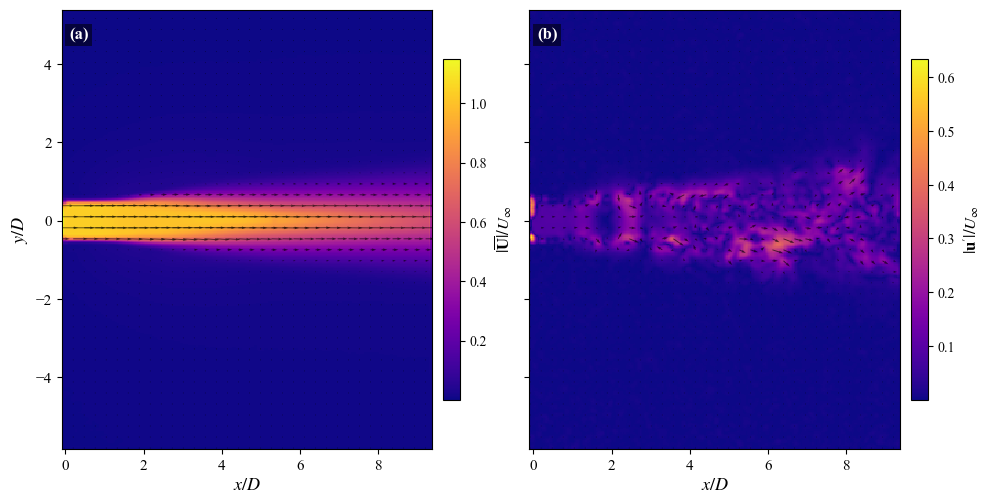

Saved PNG: f:\TFG_datos\code\figures\thesis\run1_snapshot1_mean_fluctuation_comparison.png
Saved PDF: f:\TFG_datos\code\figures\thesis\run1_snapshot1_mean_fluctuation_comparison.pdf


In [3]:
def load_mean_and_fluctuating_snapshot(run_id: int, snapshot_idx: int):
    """Load the run mean and one stored fluctuating velocity snapshot."""
    mat_path = DATA_DIR / f"Run{run_id}_PIV.mat"

    # Read only the required fields from the large HDF5-backed MATLAB file.
    with h5py.File(mat_path, "r") as f:
        n_snapshots = f["u"].shape[0]

        # Validate the selected snapshot before reading any full arrays.
        if not 0 <= snapshot_idx < n_snapshots:
            raise IndexError(
                f"snapshot_idx={snapshot_idx} is outside the valid range "
                f"[0, {n_snapshots - 1}] for Run {run_id}."
            )

        # Spatial coordinates and mean fields are two-dimensional arrays.
        X = f["X"][:]
        Y = f["Y"][:]
        Um = f["Um"][:]
        Vm = f["Vm"][:]

        # The stored lower-case components are the Reynolds fluctuations.
        u = f["u"][snapshot_idx, :, :]
        v = f["v"][snapshot_idx, :, :]

    return X, Y, Um, Vm, u, v


def plot_mean_fluctuation_comparison(
    X,
    Y,
    Um,
    Vm,
    u,
    v,
    output_stem: str,
    quiver_step: int = 8,
    mean_quiver_scale: float = 18,
    fluctuation_quiver_scale: float = 8,
    cmap: str = "viridis",
):
    """Plot the mean velocity field beside one fluctuating velocity field."""
    # Magnitudes are plotted as color fields; vectors are overlaid as arrows.
    mean_speed = np.sqrt(Um**2 + Vm**2)
    fluctuation_speed = np.sqrt(u**2 + v**2)

    fig, axes = plt.subplots(1, 2, figsize=(9.8, 5.2), sharex=True, sharey=True, constrained_layout=True)

    fields = [
        {
            "ax": axes[0],
            "Ux": Um,
            "Uy": Vm,
            "speed": mean_speed,
            "scale": mean_quiver_scale,
            "panel": "(a)",
            "colorbar_label": r"$|\overline{\mathbf{U}}|/U_\infty$",
        },
        {
            "ax": axes[1],
            "Ux": u,
            "Uy": v,
            "speed": fluctuation_speed,
            "scale": fluctuation_quiver_scale,
            "panel": "(b)",
            "colorbar_label": r"$|\mathbf{u}'|/U_\infty$",
        },
    ]

    for field in fields:
        ax = field["ax"]

        # pcolormesh avoids the artificial contour bands introduced by contourf.
        mesh = ax.pcolormesh(X, Y, field["speed"], cmap=cmap, shading="auto")
        cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.03)
        cbar.set_label(field["colorbar_label"], fontsize=12)
        cbar.ax.tick_params(labelsize=10)

        # Downsample the grid so arrows show direction without obscuring the color field.
        ax.quiver(
            X[::quiver_step, ::quiver_step],
            Y[::quiver_step, ::quiver_step],
            field["Ux"][::quiver_step, ::quiver_step],
            field["Uy"][::quiver_step, ::quiver_step],
            scale=field["scale"],
            color="k",
            alpha=0.65,
            linewidth=0.2,
        )

        # Panel labels are kept minimal; the caption explains the panels.
        ax.text(
            0.02,
            0.96,
            field["panel"],
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=12,
            fontweight="bold",
            color="white",
            bbox={"facecolor": "black", "edgecolor": "none", "alpha": 0.55, "pad": 2.5},
        )

        ax.set_xlabel(r"$x/D$")
        ax.set_aspect("equal")

    axes[0].set_ylabel(r"$y/D$")

    # Save both PNG and PDF versions for flexible thesis inclusion.
    png_path = FIGURE_DIR / f"{output_stem}.png"
    pdf_path = FIGURE_DIR / f"{output_stem}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()
    return png_path, pdf_path


# Figure: Reynolds decomposition visual comparison for one forced snapshot.
MEAN_FLUCT_RUN_ID = 1
MEAN_FLUCT_SNAPSHOT_IDX = 1

X, Y, Um, Vm, u, v = load_mean_and_fluctuating_snapshot(
    MEAN_FLUCT_RUN_ID,
    MEAN_FLUCT_SNAPSHOT_IDX,
)

png_path, pdf_path = plot_mean_fluctuation_comparison(
    X,
    Y,
    Um,
    Vm,
    u,
    v,
    output_stem=f"run{MEAN_FLUCT_RUN_ID}_snapshot{MEAN_FLUCT_SNAPSHOT_IDX}_mean_fluctuation_comparison",
    quiver_step=8,
    mean_quiver_scale=18,
    fluctuation_quiver_scale=10,
    cmap="plasma",
)

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")

## Actuation Phase Sampling

The forced runs are synchronized with the actuator, so one actuation period is sampled at twenty equally spaced phase positions. If $i$ denotes the snapshot index, the associated phase label is

$$
\phi_i = i \bmod 20, \qquad \phi_i \in \{0,1,\ldots,19\}.
$$

Equivalently, the phase angle inside one actuation cycle is

$$
\theta_{\phi} = \frac{2\pi\phi}{20}.
$$

The following schematic represents the actuator signal as a sinusoid and marks the twenty PIV sampling instants in one cycle. The sinusoid is only a phase reference; it is not a measured velocity signal.

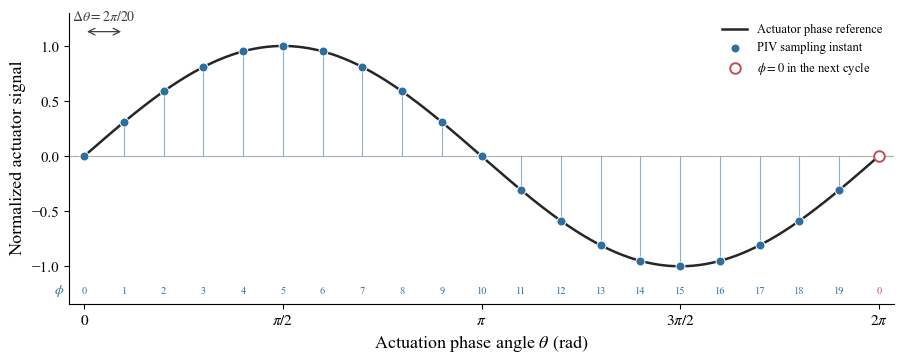

Saved PNG: F:\TFG_datos\code\figures\thesis\actuation_phase_sampling_schematic.png
Saved PDF: F:\TFG_datos\code\figures\thesis\actuation_phase_sampling_schematic.pdf


In [5]:
def plot_phase_sampling_schematic(output_stem: str = "actuation_phase_sampling_schematic"):
    """Create a schematic of the 20 phase samples within one forcing cycle."""
    # The actuator signal is represented by a unit-amplitude sinusoid.
    # Its role is only to give a visual phase reference for one period.
    n_phases = 20
    phase_labels = np.arange(n_phases)
    theta_samples = 2.0 * np.pi * phase_labels / n_phases
    signal_samples = np.sin(theta_samples)

    # Draw a smooth reference cycle and include the repeated phase at 2*pi.
    theta = np.linspace(0.0, 2.0 * np.pi, 800)
    signal = np.sin(theta)
    repeated_theta = 2.0 * np.pi
    repeated_signal = 0.0

    fig, ax = plt.subplots(figsize=(9.2, 3.8))

    # Continuous actuator phase reference.
    ax.plot(theta, signal, color="0.15", linewidth=1.8, label="Actuator phase reference")

    # Stems emphasize that the PIV system samples the cycle at discrete phases.
    ax.vlines(theta_samples, 0.0, signal_samples, color="#2F6F9F", linewidth=0.8, alpha=0.55)
    ax.scatter(
        theta_samples,
        signal_samples,
        s=42,
        color="#2F6F9F",
        edgecolor="white",
        linewidth=0.7,
        zorder=3,
        label="PIV sampling instant",
    )

    # The next sample after phase 19 belongs to the next cycle and repeats phi=0.
    ax.scatter(
        [repeated_theta],
        [repeated_signal],
        s=58,
        facecolor="white",
        edgecolor="#C44E52",
        linewidth=1.4,
        zorder=4,
        label=r"$\phi=0$ in the next cycle",
    )

    # Show the angular spacing between two consecutive PIV snapshots.
    ax.annotate(
        "",
        xy=(theta_samples[1], 1.13),
        xytext=(theta_samples[0], 1.13),
        arrowprops={"arrowstyle": "<->", "linewidth": 0.9, "color": "0.25"},
    )
    ax.text(
        0.5 * (theta_samples[0] + theta_samples[1]),
        1.20,
        r"$\Delta\theta = 2\pi/20$",
        ha="center",
        va="bottom",
        fontsize=10,
        color="0.25",
    )

    # Add compact phase labels below the signal, avoiding a crowded legend.
    label_y = -1.22
    for phase, theta_i in zip(phase_labels, theta_samples):
        ax.text(theta_i, label_y, str(phase), ha="center", va="center", fontsize=7.5, color="#2F6F9F")
    ax.text(-0.16, label_y, r"$\phi$", ha="right", va="center", fontsize=10, color="#2F6F9F")
    ax.text(repeated_theta, label_y, "0", ha="center", va="center", fontsize=7.5, color="#C44E52")

    # Use phase-angle ticks because the thesis defines the label through modulo arithmetic.
    ax.set_xticks([0, 0.5 * np.pi, np.pi, 1.5 * np.pi, 2.0 * np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax.set_xlabel(r"Actuation phase angle $\theta$ (rad)")
    ax.set_ylabel("Normalized actuator signal")

    # Keep the visual frame simple and publication-oriented.
    ax.set_xlim(-0.12, 2.0 * np.pi + 0.12)
    ax.set_ylim(-1.34, 1.30)
    ax.axhline(0.0, color="0.55", linewidth=0.8, alpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="upper right", frameon=False, fontsize=9)
    plt.tight_layout()

    # Save both bitmap and vector versions for thesis inclusion.
    png_path = FIGURE_DIR / f"{output_stem}.png"
    pdf_path = FIGURE_DIR / f"{output_stem}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()
    return png_path, pdf_path


png_path, pdf_path = plot_phase_sampling_schematic()
print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")

The schematic shows one complete actuation cycle divided into twenty equally spaced PIV sampling instants. The blue markers correspond to phase labels $\phi=0,1,\ldots,19$, while the open marker at $2\pi$ indicates that the next sample returns to $\phi=0$ in the following cycle. This visualizes the modulo convention used in the dataset: the phase label is not an additional measured variable, but a deterministic label assigned from the snapshot index because the acquisition is synchronized with the actuator.

## Manifold Hypothesis Schematic

The manifold hypothesis states that observations represented in a high-dimensional ambient space may be concentrated near a geometric object with a much smaller intrinsic dimension. A Swiss roll is a standard synthetic example because it is a two-dimensional surface embedded in three-dimensional space: each point is described by three observed coordinates, but two latent coordinates are sufficient to move along the surface.

This schematic is not a result obtained from the PIV dataset. Its purpose is only conceptual: in the thesis, each PIV snapshot is treated as one point in an ambient space with dimension equal to the number of velocity measurements, while intrinsic dimension estimation is used to test whether the cloud of snapshots behaves as if it were concentrated near a lower-dimensional structure.


In [6]:
def generate_swiss_roll(n_points: int = 1800, noise: float = 0.0, seed: int = 7):
    """Generate a synthetic Swiss roll manifold.

    The surface is intrinsically two-dimensional because each point is determined
    by the roll coordinate t and the height coordinate h. It is embedded in an
    ambient three-dimensional coordinate system for visualization.
    """
    rng = np.random.default_rng(seed)

    # The latent coordinate t controls the position along the rolled direction.
    t = 1.5 * np.pi * (1.0 + 2.0 * rng.random(n_points))

    # The second latent coordinate controls the vertical position on the sheet.
    h = 18.0 * rng.random(n_points)

    # Embed the two latent coordinates into three observed coordinates.
    x = t * np.cos(t)
    y = h
    z = t * np.sin(t)

    if noise > 0:
        x = x + rng.normal(0.0, noise, n_points)
        y = y + rng.normal(0.0, noise, n_points)
        z = z + rng.normal(0.0, noise, n_points)

    return x, y, z, t, h


def plot_swiss_roll_manifold(output_stem: str = "manifold_hypothesis_swiss_roll"):
    """Create a thesis-ready Swiss roll schematic and save it as PNG and PDF."""
    x, y, z, t, h = generate_swiss_roll()

    # The left panel shows the observed ambient coordinates; the right panel
    # shows the two latent coordinates that parametrize the same data.
    fig = plt.figure(figsize=(10.0, 4.4))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.18, 1.0, 0.04], wspace=0.16)
    ax_3d = fig.add_subplot(gs[0, 0], projection="3d")
    ax_2d = fig.add_subplot(gs[0, 1])
    cax = fig.add_subplot(gs[0, 2])

    scatter_3d = ax_3d.scatter(
        x,
        y,
        z,
        c=t,
        cmap="viridis",
        s=8,
        alpha=0.86,
        linewidths=0,
        rasterized=True,
    )

    ax_2d.scatter(
        t,
        h,
        c=t,
        cmap="viridis",
        s=8,
        alpha=0.86,
        linewidths=0,
        rasterized=True,
    )

    cbar = fig.colorbar(scatter_3d, cax=cax)
    cbar.set_label("Latent coordinate", fontsize=11)
    cbar.ax.tick_params(labelsize=9)

    # The 3D axes are intentionally kept minimal because the coordinates are
    # schematic; the caption explains that these are ambient coordinates.
    ax_3d.view_init(elev=18, azim=-64)
    ax_3d.grid(True, alpha=0.25)
    ax_3d.set_box_aspect((1.35, 0.9, 1.0))
    ax_3d.set_xticklabels([])
    ax_3d.set_yticklabels([])
    ax_3d.set_zticklabels([])
    ax_3d.tick_params(axis="both", which="major", length=0, pad=0)
    ax_3d.text2D(0.02, 0.96, "(a)", transform=ax_3d.transAxes, fontsize=12)

    # Intrinsic-coordinate labels for the unrolled manifold.
    ax_2d.set_xlabel(r"$z_1$", fontsize=12)
    ax_2d.set_ylabel(r"$z_2$", fontsize=12)
    ax_2d.grid(True, alpha=0.28)
    ax_2d.tick_params(axis="both", which="major", labelsize=9)
    ax_2d.text(0.02, 0.96, "(b)", transform=ax_2d.transAxes, fontsize=12)

    png_path = FIGURE_DIR / f"{output_stem}.png"
    pdf_path = FIGURE_DIR / f"{output_stem}.pdf"

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return png_path, pdf_path


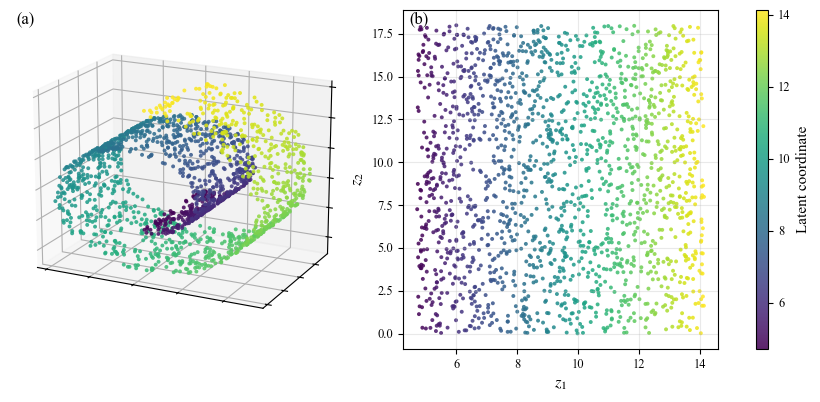

Saved PNG: F:\TFG_datos\code\figures\thesis\manifold_hypothesis_swiss_roll.png
Saved PDF: F:\TFG_datos\code\figures\thesis\manifold_hypothesis_swiss_roll.pdf


In [7]:
# Figure 2: conceptual illustration of the manifold hypothesis.
png_path, pdf_path = plot_swiss_roll_manifold()

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")


The generated figure should be read as a schematic illustration rather than as empirical evidence. Panel (a) shows the same observations in a three-dimensional ambient space, where the data form a curved Swiss roll. Panel (b) shows that the same points can be parametrized by two intrinsic coordinates. This is the conceptual situation that motivates the intrinsic-dimension analysis in the thesis: the PIV snapshots are measured in a very high-dimensional ambient space, but their dominant organization may require far fewer coordinates.


## PCA/POD Cumulative Fraction of Variance Explained

For PCA/POD, the fraction of variance explained by the first $q$ components is computed from the explained-variance ratios $r_j$ as

$$
\mathrm{FVE}(q) = \sum_{j=1}^{q} r_j.
$$

The stored file `code/pca_data/RUN2_PCA.npz` already contains the PCA scores and the vector of explained-variance ratios for RUN2, so the original velocity snapshots do not need to be loaded again. The following figure plots $\mathrm{FVE}(q)$ for the first $500$ PCA/POD components and marks the component counts used later in the supervised-learning experiments.

In [8]:
def load_run_pca_fve(run_id: int = 2):
    """Load cumulative PCA/POD FVE from the stored PCA cache.

    The cache contains the explained-variance ratio of each PCA component,
    so this function avoids loading the original velocity fields.
    """
    pca_path = CODE_DIR / "pca_data" / f"RUN{run_id}_PCA.npz"

    # Read only the small one-dimensional explained-variance array.
    with np.load(pca_path) as data:
        explained_variance_ratio = data["explained_variance_ratio"].astype(float)

    # The cumulative sum gives the FVE retained by the first q components.
    cumulative_fve = np.cumsum(explained_variance_ratio)
    component_numbers = np.arange(1, cumulative_fve.size + 1)

    return component_numbers, cumulative_fve


def plot_run2_pca_cumulative_fve(
    selected_components=(10, 50, 100, 200, 500),
    threshold: float = 0.95,
    output_stem: str = "pca_fve_run2",
):
    """Plot the cumulative FVE curve for RUN2 and save it for LaTeX."""
    component_numbers, cumulative_fve = load_run_pca_fve(run_id=2)

    # Locate the first component count that reaches the selected FVE threshold.
    threshold_idx = int(np.searchsorted(cumulative_fve, threshold) + 1)
    threshold_value = float(cumulative_fve[threshold_idx - 1])

    # Keep only requested component counts present in the stored PCA cache.
    selected_components = np.asarray(selected_components, dtype=int)
    selected_components = selected_components[selected_components <= cumulative_fve.size]
    selected_fve = cumulative_fve[selected_components - 1]

    fig, ax = plt.subplots(figsize=(7.2, 4.6))

    # Main cumulative FVE curve.
    ax.plot(
        component_numbers,
        cumulative_fve,
        color="#2F6F9F",
        linewidth=2.0,
        label="Cumulative FVE",
    )

    # Mark the dimensions used in later PCA-based prediction experiments.
    ax.scatter(
        selected_components,
        selected_fve,
        s=42,
        color="#C44E52",
        edgecolor="white",
        linewidth=0.7,
        zorder=3,
        label="Selected dimensions",
    )

    # Show the 95% threshold because it is used as a denoising reference.
    ax.axhline(threshold, color="0.35", linestyle="--", linewidth=1.0, alpha=0.8)
    ax.axvline(threshold_idx, color="0.35", linestyle="--", linewidth=1.0, alpha=0.8)
    ax.text(
        threshold_idx + 8,
        threshold - 0.055,
        rf"${threshold * 100:.0f}\%$ at $q={threshold_idx}$",
        fontsize=10,
        color="0.25",
    )

    # Axis labels are kept explicit; the thesis caption supplies the title.
    ax.set_xlabel("Number of PCA/POD components")
    ax.set_ylabel("Cumulative fraction of variance explained")
    ax.set_xlim(0, cumulative_fve.size + 8)
    ax.set_ylim(0.35, 1.005)
    ax.grid(True, alpha=0.28)
    ax.legend(frameon=False, loc="lower right")
    plt.tight_layout()

    # Save both formats: PNG for quick inspection and PDF for LaTeX inclusion.
    png_path = FIGURE_DIR / f"{output_stem}.png"
    pdf_path = FIGURE_DIR / f"{output_stem}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    summary = {
        "selected_fve": dict(zip(selected_components.tolist(), selected_fve.tolist())),
        "threshold": threshold,
        "threshold_component": threshold_idx,
        "threshold_fve": threshold_value,
        "png_path": png_path,
        "pdf_path": pdf_path,
    }
    return summary


run2_pca_fve_summary = plot_run2_pca_cumulative_fve()

for q, value in run2_pca_fve_summary["selected_fve"].items():
    print(f"q={q:3d}: cumulative FVE = {value:.3f}")

print(
    f"{run2_pca_fve_summary['threshold']:.0%} FVE is first reached at "
    f"q={run2_pca_fve_summary['threshold_component']} "
    f"(FVE={run2_pca_fve_summary['threshold_fve']:.3f})."
)
print(f"Saved PNG: {run2_pca_fve_summary['png_path']}")
print(f"Saved PDF: {run2_pca_fve_summary['pdf_path']}")

q= 10: cumulative FVE = 0.886
q= 50: cumulative FVE = 0.944
q=100: cumulative FVE = 0.964
q=200: cumulative FVE = 0.981
q=500: cumulative FVE = 0.995
95% FVE is first reached at q=61 (FVE=0.950).
Saved PNG: X:\TFG_datos\code\figures\thesis\pca_fve_run2.png
Saved PDF: X:\TFG_datos\code\figures\thesis\pca_fve_run2.pdf


The cumulative curve rises rapidly during the first components and then flattens. The first $10$ PCA/POD components retain $88.6\%$ of the variance, while $50$ components retain $94.4\%$. The $95\%$ threshold is first reached at $q=61$, and $500$ components retain $99.5\%$ of the variance stored in the cache. This confirms that RUN2 is strongly linearly compressible: most of the fluctuation energy is concentrated in a relatively small number of modes, although the final few percent of variance require many additional components. For the thesis, this justifies using PCA/POD as the main linear baseline before comparing it with sparse, spectral, and nonlinear representations.

## RUN2 PCA/POD Spatial Modes

The cumulative FVE curve quantifies how much variance is retained by the first $q$ PCA/POD components, but it does not show what spatial structures those components represent. The stored POD modes in `code/data/Run2_PIV.mat` are therefore used to visualize the leading spatial patterns. For mode $j$, the flattened vector is split into its horizontal and vertical components,

$$
\boldsymbol{\phi}_j = \left(\boldsymbol{\phi}^{(u)}_j,\boldsymbol{\phi}^{(v)}_j\right),
$$

and reshaped onto the PIV grid. The plotted scalar field is the normalized mode magnitude,

$$
M_j(x,y) = \frac{\sqrt{\left(\phi^{(u)}_j(x,y)\right)^2 + \left(\phi^{(v)}_j(x,y)\right)^2}}{\max_{x,y}\sqrt{\left(\phi^{(u)}_j(x,y)\right)^2 + \left(\phi^{(v)}_j(x,y)\right)^2}}.
$$

The normalization is applied separately to each panel so that the spatial support of each mode can be compared visually. The variance percentages printed in the panels give the contribution of each individual PCA/POD mode.

In [ ]:
def load_run_pod_modes(run_id: int = 2, n_modes: int = 6):
    """Load stored PCA/POD spatial modes without loading velocity snapshots.

    The raw MATLAB file contains the POD/PCA spatial modes in Phi. Only the
    selected leading rows of Phi are read, so the full velocity arrays are not
    loaded into memory.
    """
    mat_path = DATA_DIR / f"Run{run_id}_PIV.mat"
    pca_path = CODE_DIR / "pca_data" / f"RUN{run_id}_PCA.npz"

    # Read the shared grid and the first n_modes spatial modes from the raw file.
    with h5py.File(mat_path, "r") as f:
        X = f["X"][:]
        Y = f["Y"][:]
        Phi = f["Phi"][:n_modes, :]

    # Use the stored PCA cache for the variance contribution of each mode.
    with np.load(pca_path) as data:
        explained_variance_ratio = data["explained_variance_ratio"][:n_modes].astype(float)

    # Each mode stacks all u-values followed by all v-values.
    n_grid = X.size
    modes = []
    for phi in Phi:
        u_mode = phi[:n_grid].reshape(X.shape)
        v_mode = phi[n_grid:2 * n_grid].reshape(X.shape)
        modes.append((u_mode, v_mode))

    return X, Y, modes, explained_variance_ratio


def plot_run2_pod_modes(
    run_id: int = 2,
    n_modes: int = 6,
    n_cols: int = 3,
    figsize=(10.2, 5.4),
    cmap: str = "plasma",
    normalize_each_mode: bool = True,
    magnitude_vmin: float = 0.0,
    magnitude_vmax: float | None = 1.0,
    show_quiver: bool = True,
    quiver_step: int = 14,
    quiver_scale: float = 8.0,
    quiver_color: str = "white",
    quiver_alpha: float = 0.72,
    quiver_width: float = 0.0022,
    quiver_headwidth: float = 3.0,
    quiver_normalize: bool = True,
    panel_title_fontsize: int = 11,
    fve_label_fontsize: int = 10,
    axis_label_fontsize: int = 12,
    tick_labelsize: int = 9,
    show_fve_in_title: bool = True,
    colorbar_label: str | None = None,
    colorbar_fraction: float = 0.026,
    colorbar_pad: float = 0.018,
    dpi: int = 300,
    output_stem: str = "pca_run2_modes",
):
    """Plot leading RUN2 PCA/POD modes with tunable visual settings.

    The most frequently adjusted choices, such as colormap, quiver density,
    quiver scale, panel layout, and colorbar spacing, are exposed as arguments
    so the final thesis figure can be tuned without editing the plotting body.
    """
    X, Y, modes, explained_variance_ratio = load_run_pod_modes(run_id=run_id, n_modes=n_modes)

    # Compute all magnitudes first so global normalization can be selected.
    magnitudes = [np.sqrt(u_mode**2 + v_mode**2) for u_mode, v_mode in modes]
    global_magnitude_max = max(float(np.nanmax(magnitude)) for magnitude in magnitudes)

    # The number of rows adapts to n_modes and n_cols.
    n_rows = int(np.ceil(n_modes / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        squeeze=False,
        constrained_layout=True,
    )
    axes_flat = axes.ravel()

    if colorbar_label is None:
        colorbar_label = "Normalized mode magnitude" if normalize_each_mode else "Mode magnitude"

    mesh = None
    for mode_idx, (ax, (u_mode, v_mode), magnitude) in enumerate(
        zip(axes_flat, modes, magnitudes), start=1
    ):
        # Per-mode normalization emphasizes spatial support; global normalization
        # preserves relative amplitude differences between modes.
        local_magnitude_max = float(np.nanmax(magnitude))
        if normalize_each_mode:
            magnitude_scale = local_magnitude_max
        else:
            magnitude_scale = global_magnitude_max

        magnitude_plot = magnitude / magnitude_scale if magnitude_scale > 0 else magnitude
        vmax = magnitude_vmax if magnitude_vmax is not None else float(np.nanmax(magnitude_plot))

        mesh = ax.pcolormesh(
            X,
            Y,
            magnitude_plot,
            cmap=cmap,
            shading="auto",
            vmin=magnitude_vmin,
            vmax=vmax,
            rasterized=True,
        )

        if show_quiver:
            # Arrow normalization can be disabled if absolute mode amplitudes
            # should control arrow length.
            if quiver_normalize and local_magnitude_max > 0:
                u_plot = u_mode / local_magnitude_max
                v_plot = v_mode / local_magnitude_max
            else:
                u_plot = u_mode
                v_plot = v_mode

            ax.quiver(
                X[::quiver_step, ::quiver_step],
                Y[::quiver_step, ::quiver_step],
                u_plot[::quiver_step, ::quiver_step],
                v_plot[::quiver_step, ::quiver_step],
                color=quiver_color,
                alpha=quiver_alpha,
                scale=quiver_scale,
                width=quiver_width,
                headwidth=quiver_headwidth,
            )

        # Place mode labels outside the plotted field so they do not obscure data.
        panel_label = chr(96 + mode_idx)
        if show_fve_in_title:
            panel_title = (
                f"({panel_label}) Mode {mode_idx}\n"
                f"FVE = {100 * explained_variance_ratio[mode_idx - 1]:.1f}%"
            )
            title_fontsize = fve_label_fontsize
        else:
            panel_title = f"({panel_label}) Mode {mode_idx}"
            title_fontsize = panel_title_fontsize
        ax.set_title(panel_title, fontsize=title_fontsize, pad=7)

        ax.set_aspect("equal")
        ax.tick_params(axis="both", labelsize=tick_labelsize)

    # Hide unused panels if n_modes does not fill the rectangular grid.
    for ax in axes_flat[n_modes:]:
        ax.set_visible(False)

    for row_idx in range(n_rows):
        axes[row_idx, 0].set_ylabel(r"$y/D$", fontsize=axis_label_fontsize)
    for col_idx in range(n_cols):
        axes[n_rows - 1, col_idx].set_xlabel(r"$x/D$", fontsize=axis_label_fontsize)

    visible_axes = [ax for ax in axes_flat[:n_modes] if ax.get_visible()]
    cbar = fig.colorbar(mesh, ax=visible_axes, fraction=colorbar_fraction, pad=colorbar_pad)
    cbar.set_label(colorbar_label)
    cbar.ax.tick_params(labelsize=tick_labelsize)

    png_path = FIGURE_DIR / f"{output_stem}.png"
    pdf_path = FIGURE_DIR / f"{output_stem}.pdf"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    summary = {
        "explained_variance_ratio": explained_variance_ratio,
        "cumulative_fve": float(np.sum(explained_variance_ratio)),
        "png_path": png_path,
        "pdf_path": pdf_path,
    }
    return summary


# Tune the final appearance of the thesis figure from this dictionary.
POD_MODE_PLOT_SETTINGS = {
    "run_id": 2,
    "n_modes": 6,
    "n_cols": 3,
    "figsize": (10.2, 5.8),
    "cmap": "plasma",
    "normalize_each_mode": True,
    "magnitude_vmin": 0.0,
    "magnitude_vmax": 1.0,
    "show_quiver": True,
    "quiver_step": 8,
    "quiver_scale": 16.0,
    "quiver_color": "white",
    "quiver_alpha": 0.72,
    "quiver_width": 0.0022,
    "quiver_headwidth": 3.0,
    "quiver_normalize": True,
    "panel_title_fontsize": 11,
    "fve_label_fontsize": 10,
    "axis_label_fontsize": 12,
    "tick_labelsize": 9,
    "show_fve_in_title": True,
    "colorbar_fraction": 0.026,
    "colorbar_pad": 0.018,
    "dpi": 300,
    "output_stem": "pca_run2_modes",
}

run2_pod_modes_summary = plot_run2_pod_modes(**POD_MODE_PLOT_SETTINGS)

for idx, value in enumerate(run2_pod_modes_summary["explained_variance_ratio"], start=1):
    print(f"Mode {idx}: FVE = {100 * value:.2f}%")
print(f"First six modes: cumulative FVE = {100 * run2_pod_modes_summary['cumulative_fve']:.2f}%")
print(f"Saved PNG: {run2_pod_modes_summary['png_path']}")
print(f"Saved PDF: {run2_pod_modes_summary['pdf_path']}")

Mode 1: FVE = 39.67%
Mode 2: FVE = 24.44%
Mode 3: FVE = 12.76%
Mode 4: FVE = 5.69%
Mode 5: FVE = 1.87%
Mode 6: FVE = 1.76%
First six modes: cumulative FVE = 86.19%
Saved PNG: X:\TFG_datos\code\figures\thesis\pca_run2_modes.png
Saved PDF: X:\TFG_datos\code\figures\thesis\pca_run2_modes.pdf


The first six PCA/POD modes retain $86.2\%$ of the RUN2 variance, with the first three modes contributing $39.7\%$, $24.4\%$, and $12.8\%$, respectively. The plotted mode magnitudes are concentrated around the jet centerline and the shear-layer region rather than being uniformly distributed over the full PIV window. This indicates that the leading PCA/POD modes are associated with organized fluctuation structures in the jet, not with spatially homogeneous variability.

The later modes shown here have smaller individual variance contributions and display more spatial oscillations along the streamwise direction. This is consistent with the cumulative FVE curve: a few dominant modes capture the largest coherent fluctuations, while additional modes are needed to represent finer spatial variability. The figure also shows a limitation of PCA/POD for physical interpretation. The modes are not strictly localized, because PCA/POD enforces orthogonal dense modes. This motivates the comparison with Sparse PCA, whose purpose is to trade some reconstruction efficiency for spatially more localized components.

## SPOD Spectral Diagnostics Across Runs

The SPOD decomposition gives, for each frequency bin $f$, a set of eigenvalues $\lambda_j(f)$ ordered by modal energy. For one run, the total resolved SPOD energy at each frequency is computed as

$$
E_{\mathrm{SPOD}}(f) = \sum_{j=1}^{n_m} \lambda_j(f),
$$

where $n_m$ is the number of stored SPOD modes. Since the SPOD files were computed with snapshot time step $\Delta t=1$, the stored frequency is in cycles per snapshot. For forced runs, the physical Strouhal frequency is obtained from

$$
St = f\,\frac{St_{\mathrm{act}}}{0.05},
$$

because all forced runs contain twenty PIV snapshots per actuation cycle. The spectra below are normalized by their maximum value in each run so that the locations of energetic frequencies can be compared across actuation frequencies.

In [ ]:
import gc
import math
import re

import pandas as pd

from scipy.signal import welch


def load_run_strouhal_map(info_path: Path | None = None):
    """Read the run-to-Strouhal mapping from code/data/info.txt."""
    if info_path is None:
        info_path = DATA_DIR / "info.txt"

    run_to_st = {}
    pattern = re.compile(r"\*?Run\s+(\d+)\s+([0-9.]+)")
    for line in info_path.read_text(encoding="utf-8", errors="replace").splitlines():
        match = pattern.search(line)
        if match:
            run_to_st[int(match.group(1))] = float(match.group(2))

    return run_to_st


RUN_STROUHAL = load_run_strouhal_map()


def physical_st_from_spod_freqs(freqs, st_act: float):
    """Convert SPOD frequency bins from cycles/snapshot to Strouhal number."""
    if st_act <= 0:
        raise ValueError("Physical Strouhal scaling is only defined for forced runs with St_act > 0.")
    return freqs * (st_act / 0.05)


def load_spod_freqs_eigvals(run_id: int):
    """Load only the lightweight SPOD frequency and eigenvalue arrays."""
    spod_path = CODE_DIR / "SPOD_data" / f"RUN{run_id}_PIV_SPOD.npz"
    with np.load(spod_path) as data:
        freqs = data["freqs"].astype(float)
        eigvals = data["eigvals"].astype(float)
    return freqs, eigvals


def normalize_energy_curve(energy, mode: str = "max", floor: float = 1e-10):
    """Normalize an energy curve and clip it to a positive floor for log plots."""
    energy = np.asarray(energy, dtype=float)
    if mode == "max":
        scale = np.nanmax(energy)
    elif mode == "sum":
        scale = np.nansum(energy)
    else:
        raise ValueError(f"Unknown normalization mode: {mode}")

    normalized = energy / scale if scale > 0 else energy
    return np.clip(normalized, floor, None)


def add_harmonic_markers(ax, st_act: float, harmonics=(1, 2, 3), color="0.55", alpha=0.55):
    """Add vertical reference lines at selected actuation harmonics."""
    xmin, xmax = ax.get_xlim()
    for harmonic in harmonics:
        st_h = harmonic * st_act
        if xmin <= st_h <= xmax:
            ax.axvline(st_h, color=color, linestyle="--", linewidth=0.75, alpha=alpha)


In [ ]:
def plot_spod_total_energy_grid(
    run_ids=tuple(range(2, 26)),
    n_cols: int = 4,
    figsize_per_panel=(2.9, 2.15),
    eig_modes_to_sum: int | None = None,
    normalize_mode: str = "max",
    y_floor: float = 1e-7,
    line_color: str = "#2F6F9F",
    line_width: float = 1.15,
    show_harmonics: bool = True,
    harmonic_numbers=(1, 2, 3),
    tick_labelsize: int = 8,
    title_fontsize: int = 9,
    axis_label_fontsize: int = 10,
    output_stem: str = "spod_total_energy_grid_forced_runs",
    dpi: int = 300,
):
    """Plot normalized total SPOD energy spectra for a selected set of runs."""
    run_ids = tuple(run_ids)
    n_rows = int(math.ceil(len(run_ids) / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        squeeze=False,
        constrained_layout=True,
    )
    axes_flat = axes.ravel()

    peak_rows = []
    for panel_idx, (ax, run_id) in enumerate(zip(axes_flat, run_ids), start=1):
        st_act = RUN_STROUHAL[run_id]
        freqs, eigvals = load_spod_freqs_eigvals(run_id)
        freqs_st = physical_st_from_spod_freqs(freqs, st_act)

        if eig_modes_to_sum is None:
            total_energy = eigvals.sum(axis=1)
        else:
            total_energy = eigvals[:, :eig_modes_to_sum].sum(axis=1)

        energy_norm = normalize_energy_curve(total_energy, mode=normalize_mode, floor=y_floor)
        ax.plot(freqs_st, energy_norm, color=line_color, linewidth=line_width)
        ax.set_yscale("log")
        ax.set_ylim(y_floor, 1.25)
        ax.set_xlim(freqs_st.min(), freqs_st.max())
        ax.grid(True, which="both", alpha=0.22, linewidth=0.5)
        ax.tick_params(axis="both", labelsize=tick_labelsize)

        if show_harmonics:
            add_harmonic_markers(ax, st_act, harmonics=harmonic_numbers)

        panel_label = chr(96 + panel_idx) if panel_idx <= 26 else str(panel_idx)
        ax.set_title(
            f"({panel_label}) RUN{run_id}, $St_{{act}}={st_act:.2f}$",
            fontsize=title_fontsize,
            pad=5,
        )

        peak_idx = int(np.argmax(total_energy))
        peak_rows.append({
            "run_id": run_id,
            "st_act": st_act,
            "peak_st": float(freqs_st[peak_idx]),
            "peak_energy_norm": float(energy_norm[peak_idx]),
        })

    for ax in axes_flat[len(run_ids):]:
        ax.set_visible(False)

    for row_idx in range(n_rows):
        axes[row_idx, 0].set_ylabel("Norm. total energy", fontsize=axis_label_fontsize)
    for col_idx in range(n_cols):
        axes[n_rows - 1, col_idx].set_xlabel(r"$St$", fontsize=axis_label_fontsize)

    png_path = FIGURE_DIR / f"{output_stem}.png"
    pdf_path = FIGURE_DIR / f"{output_stem}.pdf"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    return pd.DataFrame(peak_rows), png_path, pdf_path


SPOD_TOTAL_ENERGY_GRID_SETTINGS = {
    "run_ids": tuple(range(2, 26)),
    "n_cols": 4,
    "figsize_per_panel": (2.9, 2.15),
    "eig_modes_to_sum": None,
    "normalize_mode": "max",
    "y_floor": 1e-7,
    "line_color": "#2F6F9F",
    "line_width": 1.15,
    "show_harmonics": True,
    "harmonic_numbers": (1, 2, 3),
    "tick_labelsize": 8,
    "title_fontsize": 9,
    "axis_label_fontsize": 10,
    "output_stem": "spod_total_energy_grid_forced_runs",
    "dpi": 300,
}

spod_total_energy_peaks, spod_total_energy_png, spod_total_energy_pdf = plot_spod_total_energy_grid(
    **SPOD_TOTAL_ENERGY_GRID_SETTINGS
)

print(spod_total_energy_peaks.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"Saved PNG: {spod_total_energy_png}")
print(f"Saved PDF: {spod_total_energy_pdf}")

 run_id  st_act  peak_st  peak_energy_norm
      2  0.0500   0.0508            1.0000
      3  0.1000   0.1016            1.0000
      4  0.1500   0.1523            1.0000
      5  0.2000   0.2031            1.0000
      6  0.2500   0.2539            1.0000
      7  0.3000   0.3047            1.0000
      8  0.3500   0.3555            1.0000
      9  0.4000   0.4062            1.0000
     10  0.4500   0.4570            1.0000
     11  0.5000   0.5078            1.0000
     12  0.5500   0.5586            1.0000
     13  0.6000   0.6094            1.0000
     14  0.6500   0.6602            1.0000
     15  0.7000   0.7109            1.0000
     16  0.7500   0.7617            1.0000
     17  0.8000   0.8125            1.0000
     18  0.8500   0.8633            1.0000
     19  0.9000   0.9141            1.0000
     20  0.9500   0.9648            1.0000
     21  1.0000   1.0156            1.0000
     22  1.0500   0.4922            1.0000
     23  1.1000   0.5156            1.0000
     24  1.

The total-energy spectra show that, for most forced runs, the strongest resolved SPOD energy occurs at the frequency bin closest to the actuation Strouhal number. The peak positions are slightly shifted from the nominal $St_{\mathrm{act}}$ values because the SPOD frequency grid is discrete. The first harmonics are also visible in many low and intermediate actuation cases, although their relative amplitude decreases with harmonic order. The highest actuation cases are less uniform: RUN22, RUN23, and RUN25 have their largest total-energy peak at a lower-frequency bin rather than at the nominal actuation bin. This suggests that, for those cases, the strongest organized fluctuation energy in the resolved SPOD spectrum is not only the directly forced frequency but also a lower-frequency response of the jet.

## RUN2 SPOD and PCA Temporal Spectra

The SPOD spectrum gives the frequency-dependent eigenvalues $\lambda_j(f)$ of the cross-spectral density tensor. PCA/POD, instead, ranks spatial modes by total variance over all times. To compare both views for RUN2, the temporal coefficients of the first PCA modes are transformed into frequency space with Welch's method. The two panels therefore compare frequency-localized SPOD energy with the power spectral density of the leading PCA temporal scores.

In [ ]:
def load_run_pca_score_psd(run_id: int = 2, n_modes: int = 5, nperseg: int = 256):
    """Compute Welch PSDs for the first PCA temporal score coordinates."""
    pca_path = CODE_DIR / "pca_data" / f"RUN{run_id}_PCA.npz"
    with np.load(pca_path) as data:
        scores = data["scores"][:, :n_modes].astype(float)

    psd_list = []
    psd_freqs = None
    for mode_idx in range(n_modes):
        freqs, psd = welch(
            scores[:, mode_idx],
            fs=1.0,
            nperseg=nperseg,
            detrend="constant",
            scaling="density",
        )
        if psd_freqs is None:
            psd_freqs = freqs
        psd_list.append(psd)

    return psd_freqs, np.column_stack(psd_list)


def normalize_energy_matrix(energy_matrix, mode: str = "panel_max", floor: float = 1e-10):
    """Normalize a frequency-by-mode energy matrix for log plotting."""
    energy_matrix = np.asarray(energy_matrix, dtype=float)
    if mode == "panel_max":
        scale = np.nanmax(energy_matrix)
    elif mode == "per_mode_max":
        scale = np.nanmax(energy_matrix, axis=0, keepdims=True)
    else:
        raise ValueError(f"Unknown normalization mode: {mode}")

    normalized = energy_matrix / np.maximum(scale, floor)
    return np.clip(normalized, floor, None)


def plot_run_spod_pca_modal_spectra(
    run_id: int = 2,
    n_modes: int = 5,
    nperseg: int = 256,
    normalize_mode: str = "panel_max",
    y_floor: float = 1e-8,
    figsize=(9.0, 3.9),
    cmap_name: str = "viridis",
    line_width: float = 1.35,
    show_harmonics: bool = True,
    harmonic_numbers=(1, 2, 3, 4, 5),
    output_stem: str = "run2_spod_pca_modal_spectra",
    dpi: int = 300,
):
    """Compare RUN2 SPOD eigenvalue spectra and PCA score spectra."""
    st_act = RUN_STROUHAL[run_id]

    spod_freqs, spod_eigvals = load_spod_freqs_eigvals(run_id)
    spod_freqs_st = physical_st_from_spod_freqs(spod_freqs, st_act)
    spod_energy = normalize_energy_matrix(spod_eigvals[:, :n_modes], mode=normalize_mode, floor=y_floor)

    pca_freqs, pca_psd = load_run_pca_score_psd(run_id=run_id, n_modes=n_modes, nperseg=nperseg)
    pca_freqs_st = physical_st_from_spod_freqs(pca_freqs, st_act)
    pca_energy = normalize_energy_matrix(pca_psd, mode=normalize_mode, floor=y_floor)

    colors = plt.get_cmap(cmap_name)(np.linspace(0.12, 0.88, n_modes))
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True, constrained_layout=True)
    panels = [
        {"ax": axes[0], "freqs": spod_freqs_st, "energy": spod_energy, "title": "(a) SPOD eigenvalues"},
        {"ax": axes[1], "freqs": pca_freqs_st, "energy": pca_energy, "title": "(b) PCA score spectra"},
    ]

    for panel in panels:
        ax = panel["ax"]
        for mode_idx in range(n_modes):
            ax.plot(
                panel["freqs"],
                panel["energy"][:, mode_idx],
                color=colors[mode_idx],
                linewidth=line_width,
                label=f"Mode {mode_idx + 1}",
            )
        ax.set_yscale("log")
        ax.set_ylim(y_floor, 1.35)
        ax.set_xlim(0.0, max(spod_freqs_st.max(), pca_freqs_st.max()))
        ax.set_xlabel(r"$St$")
        ax.set_title(panel["title"], fontsize=11, pad=6)
        ax.grid(True, which="both", alpha=0.25, linewidth=0.5)
        if show_harmonics:
            add_harmonic_markers(ax, st_act, harmonics=harmonic_numbers)

    axes[0].set_ylabel("Normalized energy")
    axes[1].legend(loc="upper right", fontsize=8, frameon=False)

    png_path = FIGURE_DIR / f"{output_stem}.png"
    pdf_path = FIGURE_DIR / f"{output_stem}.pdf"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    # Return the strongest bins for text interpretation.
    spod_peak_idx = np.argmax(spod_eigvals[:, 0])
    pca_peak_indices = np.argmax(pca_psd, axis=0)
    return {
        "spod_mode1_peak_st": float(spod_freqs_st[spod_peak_idx]),
        "pca_mode_peak_st": [float(pca_freqs_st[idx]) for idx in pca_peak_indices],
        "png_path": png_path,
        "pdf_path": pdf_path,
    }


RUN2_SPOD_PCA_SPECTRA_SETTINGS = {
    "run_id": 2,
    "n_modes": 5,
    "nperseg": 256,
    "normalize_mode": "panel_max",
    "y_floor": 1e-8,
    "figsize": (9.0, 3.9),
    "cmap_name": "viridis",
    "line_width": 1.35,
    "show_harmonics": True,
    "harmonic_numbers": (1, 2, 3, 4, 5),
    "output_stem": "run2_spod_pca_modal_spectra",
    "dpi": 300,
}

run2_modal_spectra_summary = plot_run_spod_pca_modal_spectra(**RUN2_SPOD_PCA_SPECTRA_SETTINGS)
print(f"SPOD mode 1 peak St: {run2_modal_spectra_summary['spod_mode1_peak_st']:.4f}")
for mode_idx, peak_st in enumerate(run2_modal_spectra_summary["pca_mode_peak_st"], start=1):
    print(f"PCA mode {mode_idx} PSD peak St: {peak_st:.4f}")
print(f"Saved PNG: {run2_modal_spectra_summary['png_path']}")
print(f"Saved PDF: {run2_modal_spectra_summary['pdf_path']}")

SPOD mode 1 peak St: 0.0508
PCA mode 1 PSD peak St: 0.0508
PCA mode 2 PSD peak St: 0.0508
PCA mode 3 PSD peak St: 0.1016
PCA mode 4 PSD peak St: 0.0508
PCA mode 5 PSD peak St: 0.1992
Saved PNG: X:\TFG_datos\code\figures\thesis\run2_spod_pca_modal_spectra.png
Saved PDF: X:\TFG_datos\code\figures\thesis\run2_spod_pca_modal_spectra.pdf


For RUN2, both decompositions detect the actuation frequency and its harmonics, but they organize the information differently. The SPOD panel shows a very sharp leading-mode peak at $St\approx0.0508$, followed by clear harmonic peaks. The lower SPOD modes remain far below the leading eigenvalue at the main spectral peaks, indicating that the coherent frequency-locked response is strongly concentrated in the first SPOD mode. The PCA coefficient spectra also contain peaks at the same frequencies, but the energy is distributed across several temporal coefficients. In particular, the first, second, and fourth PCA coefficients peak at the actuation frequency, while the third and fifth coefficients peak at higher harmonics. This illustrates the methodological difference: PCA ranks structures by total variance, whereas SPOD separates the variance by frequency before ranking modes.

## Leading SPOD Modes at Actuation Harmonics

The previous spectra identify the frequencies where SPOD energy is concentrated. To connect those peaks with spatial structures, the next figure shows the leading SPOD mode at $St_{\mathrm{act}}$, $2St_{\mathrm{act}}$, and $3St_{\mathrm{act}}$ for selected runs. The plotted vector field is the phase-aligned real part of the complex SPOD mode, and the background color is the normalized magnitude in each panel.

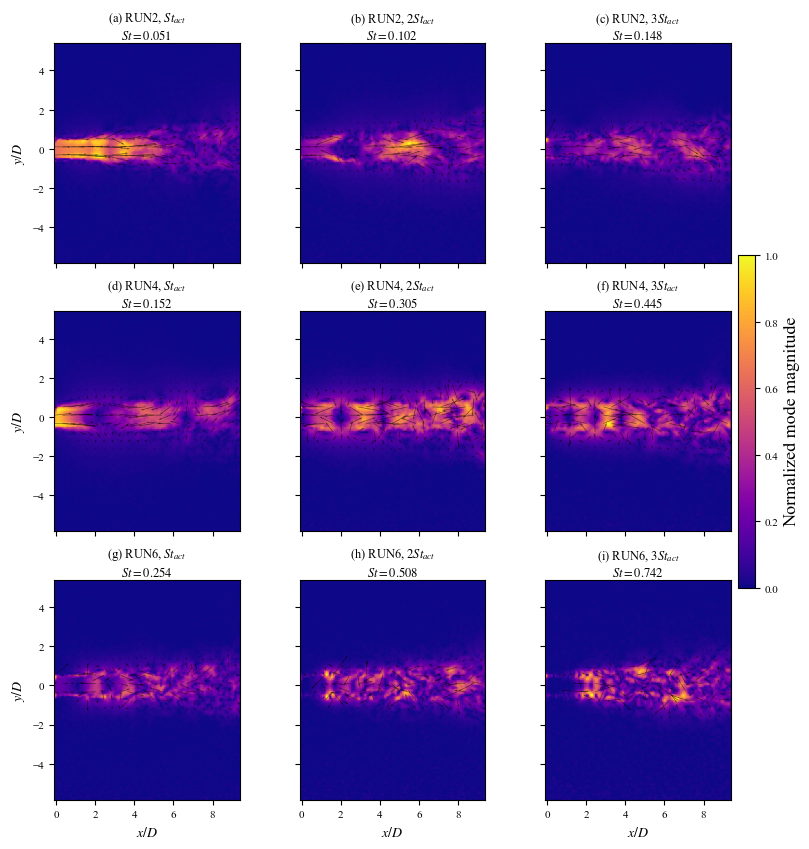

 run_id  harmonic  target_st  actual_st  freq_idx
      2         1     0.0500     0.0508        13
      2         2     0.1000     0.1016        26
      2         3     0.1500     0.1484        38
      4         1     0.1500     0.1523        13
      4         2     0.3000     0.3047        26
      4         3     0.4500     0.4453        38
      6         1     0.2500     0.2539        13
      6         2     0.5000     0.5078        26
      6         3     0.7500     0.7422        38
Saved PNG: x:\TFG_datos\code\figures\thesis\spod_harmonic_modes_runs2_6_10.png
Saved PDF: x:\TFG_datos\code\figures\thesis\spod_harmonic_modes_runs2_6_10.pdf


In [ ]:
def phase_align_complex_mode(mode_vector):
    """Fix the arbitrary complex phase of an SPOD mode for real-part plotting."""
    reference_idx = int(np.argmax(np.abs(mode_vector)))
    phase = np.angle(mode_vector[reference_idx])
    return mode_vector * np.exp(-1j * phase)


def reshape_flat_mode(mode_vector, grid_shape):
    """Split a flat SPOD vector into horizontal and vertical grid components."""
    n_grid = int(np.prod(grid_shape))
    u_mode = mode_vector[:n_grid].reshape(grid_shape)
    v_mode = mode_vector[n_grid:2 * n_grid].reshape(grid_shape)
    return u_mode, v_mode


def load_leading_spod_modes_at_harmonics(run_id: int, harmonics=(1, 2, 3)):
    """Load leading SPOD modes at selected actuation harmonics for one run.

    The compressed npz stores eigvecs as one large compressed member. Accessing
    eigvecs loads that member, so this function extracts all requested harmonic
    modes for one run at once and then releases the array before returning.
    """
    st_act = RUN_STROUHAL[run_id]
    spod_path = CODE_DIR / "SPOD_data" / f"RUN{run_id}_PIV_SPOD.npz"

    with np.load(spod_path) as data:
        freqs = data["freqs"].astype(float)
        freqs_st = physical_st_from_spod_freqs(freqs, st_act)
        X = data["X"]
        Y = data["Y"]
        eigvecs = data["eigvecs"]

        modes = []
        for harmonic in harmonics:
            target_st = harmonic * st_act
            freq_idx = int(np.argmin(np.abs(freqs_st - target_st)))
            mode_vector = np.array(eigvecs[freq_idx, 0, :], copy=True)
            mode_vector = phase_align_complex_mode(mode_vector)
            u_mode, v_mode = reshape_flat_mode(np.real(mode_vector), X.shape)
            modes.append({
                "harmonic": harmonic,
                "target_st": target_st,
                "actual_st": float(freqs_st[freq_idx]),
                "freq_idx": freq_idx,
                "u_mode": u_mode,
                "v_mode": v_mode,
            })

    del eigvecs
    gc.collect()
    return X, Y, modes


def plot_spod_harmonic_mode_grid(
    run_ids=(2, 6, 10),
    harmonics=(1, 2, 3),
    figsize_per_panel=(3.0, 2.95),
    cmap: str = "magma",
    normalize_each_panel: bool = True,
    quiver_step: int = 12,
    quiver_scale: float = 5.5,
    quiver_color: str = "k",
    quiver_alpha: float = 0.58,
    quiver_width: float = 0.0032,
    tick_labelsize: int = 8,
    title_fontsize: int = 9,
    axis_label_fontsize: int = 10,
    colorbar_label: str = "Normalized mode magnitude",
    colorbar_fraction: float = 0.022,
    colorbar_pad: float = 0.010,
    subplot_left: float = 0.060,
    subplot_right: float = 0.900,
    subplot_bottom: float = 0.070,
    subplot_top: float = 0.925,
    subplot_wspace: float = 0.020,
    subplot_hspace: float = 0.220,
    title_pad: float = 3.0,
    output_stem: str = "spod_harmonic_modes_runs2_6_10",
    dpi: int = 300,
):
    """Plot leading SPOD spatial modes at selected actuation harmonics."""
    run_ids = tuple(run_ids)
    harmonics = tuple(harmonics)
    n_rows = len(run_ids)
    n_cols = len(harmonics)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
        constrained_layout=False,
    )
    fig.subplots_adjust(
        left=subplot_left,
        right=subplot_right,
        bottom=subplot_bottom,
        top=subplot_top,
        wspace=subplot_wspace,
        hspace=subplot_hspace,
    )

    all_mode_records = []
    mesh = None
    panel_idx = 0
    for row_idx, run_id in enumerate(run_ids):
        X, Y, modes = load_leading_spod_modes_at_harmonics(run_id, harmonics=harmonics)
        for col_idx, mode_record in enumerate(modes):
            panel_idx += 1
            ax = axes[row_idx, col_idx]
            u_mode = mode_record["u_mode"]
            v_mode = mode_record["v_mode"]
            magnitude = np.sqrt(u_mode**2 + v_mode**2)
            magnitude_max = float(np.nanmax(magnitude))
            magnitude_plot = magnitude / magnitude_max if normalize_each_panel and magnitude_max > 0 else magnitude

            mesh = ax.pcolormesh(
                X,
                Y,
                magnitude_plot,
                cmap=cmap,
                shading="auto",
                vmin=0.0 if normalize_each_panel else None,
                vmax=1.0 if normalize_each_panel else None,
                rasterized=True,
            )

            if magnitude_max > 0:
                u_plot = u_mode / magnitude_max
                v_plot = v_mode / magnitude_max
            else:
                u_plot = u_mode
                v_plot = v_mode

            ax.quiver(
                X[::quiver_step, ::quiver_step],
                Y[::quiver_step, ::quiver_step],
                u_plot[::quiver_step, ::quiver_step],
                v_plot[::quiver_step, ::quiver_step],
                color=quiver_color,
                alpha=quiver_alpha,
                scale=quiver_scale,
                width=quiver_width,
                headwidth=3.0,
            )

            panel_label = chr(96 + panel_idx)
            harmonic = mode_record["harmonic"]
            harmonic_label = r"$St_{act}$" if harmonic == 1 else rf"${harmonic}St_{{act}}$"
            ax.set_title(
                f"({panel_label}) RUN{run_id}, {harmonic_label}\n"
                f"$St={mode_record['actual_st']:.3f}$",
                fontsize=title_fontsize,
                pad=title_pad,
            )
            ax.set_aspect("equal")
            ax.tick_params(axis="both", labelsize=tick_labelsize)

            all_mode_records.append({
                "run_id": run_id,
                "harmonic": harmonic,
                "target_st": mode_record["target_st"],
                "actual_st": mode_record["actual_st"],
                "freq_idx": mode_record["freq_idx"],
            })

    for row_idx in range(n_rows):
        axes[row_idx, 0].set_ylabel(r"$y/D$", fontsize=axis_label_fontsize)
    for col_idx in range(n_cols):
        axes[n_rows - 1, col_idx].set_xlabel(r"$x/D$", fontsize=axis_label_fontsize)

    cbar = fig.colorbar(mesh, ax=axes.ravel().tolist(), fraction=colorbar_fraction, pad=colorbar_pad)
    cbar.set_label(colorbar_label)
    cbar.ax.tick_params(labelsize=tick_labelsize)

    png_path = FIGURE_DIR / f"{output_stem}.png"
    pdf_path = FIGURE_DIR / f"{output_stem}.pdf"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    return pd.DataFrame(all_mode_records), png_path, pdf_path


SPOD_HARMONIC_MODE_GRID_SETTINGS = {
    "run_ids": (2, 4, 6),
    "harmonics": (1, 2, 3),
    "figsize_per_panel": (3.0, 2.95),
    "cmap": "plasma",
    "normalize_each_panel": True,
    "quiver_step": 8,
    "quiver_scale": 16.0,
    "quiver_color": "k",
    "quiver_alpha": 0.58,
    "quiver_width": 0.0032,
    "tick_labelsize": 8,
    "title_fontsize": 9,
    "axis_label_fontsize": 10,
    "colorbar_label": "Normalized mode magnitude",
    "colorbar_fraction": 0.022,
    "colorbar_pad": 0.010,
    "subplot_left": 0.060,
    "subplot_right": 0.900,
    "subplot_bottom": 0.070,
    "subplot_top": 0.925,
    "subplot_wspace": 0.020,
    "subplot_hspace": 0.220,
    "title_pad": 3.0,
    "output_stem": "spod_harmonic_modes_runs2",
    "dpi": 300,
}

spod_harmonic_mode_summary, spod_harmonic_png, spod_harmonic_pdf = plot_spod_harmonic_mode_grid(
    **SPOD_HARMONIC_MODE_GRID_SETTINGS
)

print(spod_harmonic_mode_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"Saved PNG: {spod_harmonic_png}")
print(f"Saved PDF: {spod_harmonic_pdf}")

The leading SPOD mode shapes show how the frequency content observed in the spectra is expressed spatially. For RUN2, the fundamental mode is concentrated in the near-field jet core, while the second and third harmonics shift energy downstream and show finer spatial modulation. As the actuation Strouhal number increases from RUN2 to RUN6 and RUN10, the structures become more compact in the streamwise direction and more fragmented along the shear layers. The higher harmonics show smaller-scale patterns than the fundamental mode. These observations are consistent with the interpretation that SPOD isolates frequency-specific coherent structures: changing either the actuation frequency or the harmonic changes the spatial scale and downstream organization of the leading mode.


## t-SNE Phase and Cross-Run Embeddings

The t-SNE diagnostics are used to visualize the nonlinear organization of the velocity-field snapshots after PCA preprocessing. For a forced run, the phase label is defined from the acquisition order as

$$
\phi_i = i \bmod 20, \qquad \phi_i \in \{0,1,\ldots,19\},
$$

because the experiment stores twenty snapshots per actuation cycle. The first figure computes a two-dimensional t-SNE embedding for RUN2 and colors the points by phase. The second and third figures use the stored global three-dimensional t-SNE embedding: first colored by run, and then split by forced run and colored by phase.


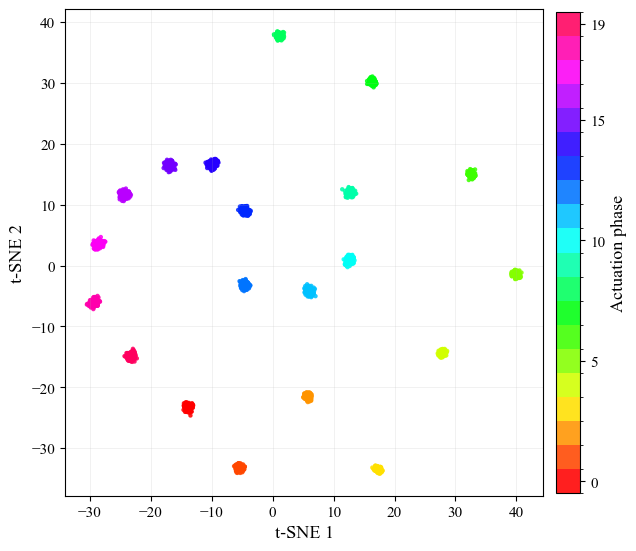

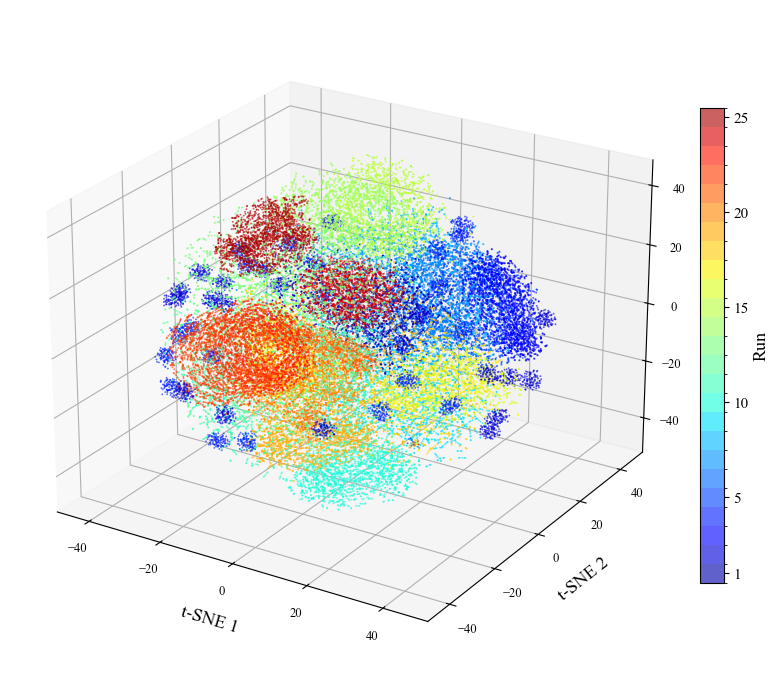

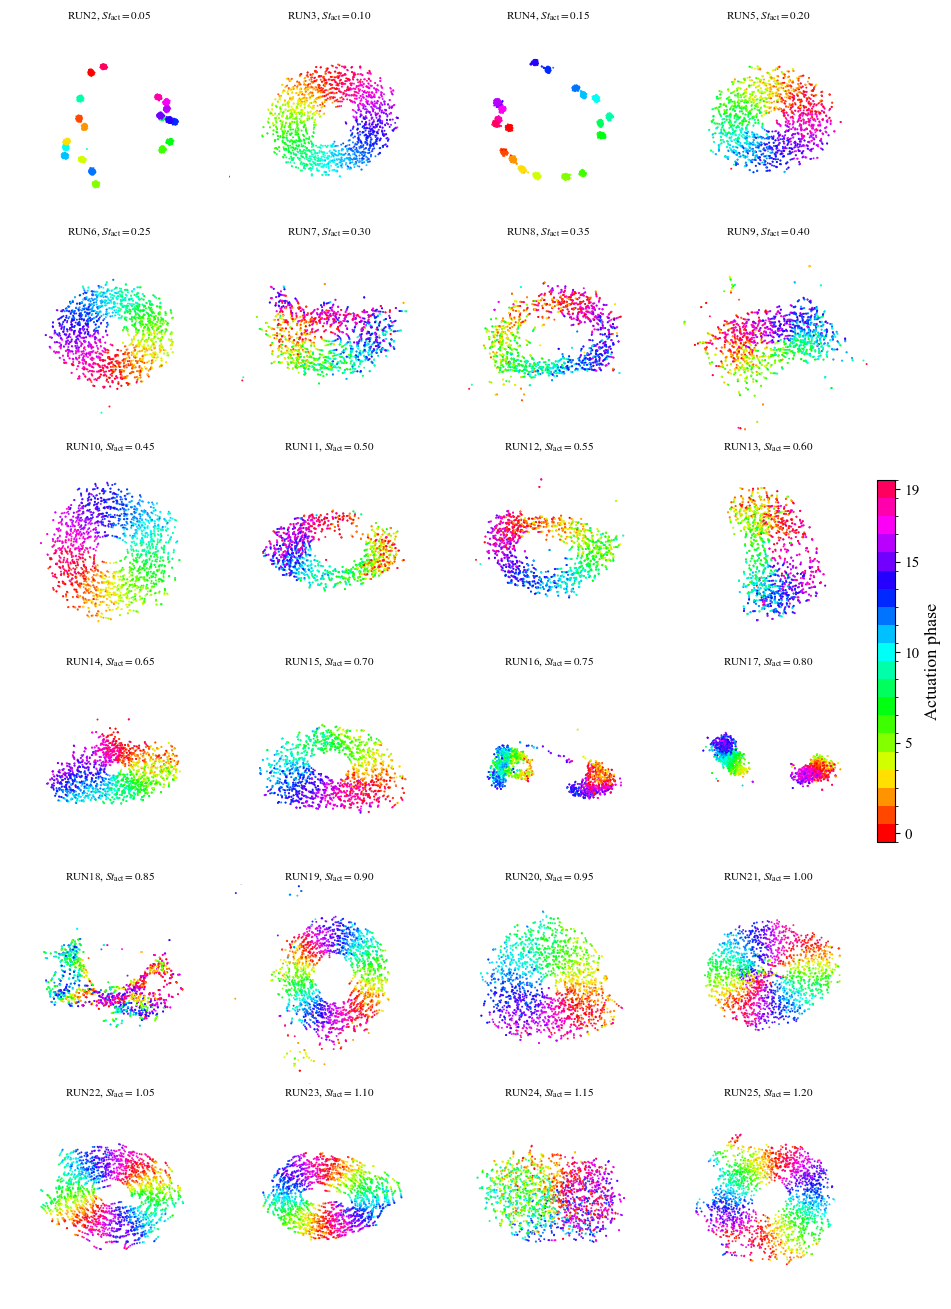

RUN2 t-SNE phase embedding
  cache: x:\TFG_datos\code\tsne_data\RUN2_tsne_phase_pca14_perp100_trials5.npz
  loaded from cache: True
  best trial: 1/5
  best KL divergence: 0.0838
  all KL values: [0.0838 0.0838 0.0838 0.0838 0.0838]
  saved PNG: x:\TFG_datos\code\figures\thesis\tsne_run2_phase_embedding.png
  saved PDF: x:\TFG_datos\code\figures\thesis\tsne_run2_phase_embedding.pdf

Global t-SNE by run
{'n_points': 50751, 'n_runs': 25, 'perplexity': 50, 'n_pca_components': 500, 'var_explained': 0.9646455413471182}
  saved PNG: x:\TFG_datos\code\figures\thesis\global_tsne_by_run.png
  saved PDF: x:\TFG_datos\code\figures\thesis\global_tsne_by_run.pdf

Global t-SNE phase grid by run
 run_id  st_act  n_points  view_elev  view_azim
      2   0.050      2030     73.981     66.767
      3   0.100      2030     21.683     23.352
      4   0.150      2030     67.601   -118.609
      5   0.200      2030     -3.784     93.956
      6   0.250      2030    -12.605    112.927
      7   0.300      2

In [6]:

import math
from time import time

import pandas as pd
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.cm import ScalarMappable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


# -----------------------------------------------------------------------------
# Tunable plotting and computation settings
# -----------------------------------------------------------------------------
RUN2_TSNE_PHASE_SETTINGS = {
    "run_id": 2,
    "st_act": 0.05,
    "n_pca_components": 14,       # 14 RUN2 PCA/POD components retain just over 90% FVE.
    "perplexity": 100,
    "n_trials": 5,
    "learning_rate": 200.0,
    "max_iter": 1000,
    "random_state_start": 0,
    "point_size": 10,
    "alpha": 0.88,
    "figsize": (6.2, 5.4),
    "output_stem": "tsne_run2_phase_embedding",
    "dpi": 300,
}

GLOBAL_TSNE_BY_RUN_SETTINGS = {
    "run_ids": tuple(range(1, 26)),
    "view_elev": 24,
    "view_azim": -58,
    "point_size": 1.8,
    "alpha": 0.62,
    "figsize": (8.4, 6.8),
    "output_stem": "global_tsne_by_run",
    "dpi": 300,
}

GLOBAL_TSNE_PHASE_GRID_SETTINGS = {
    "run_ids": tuple(range(2, 26)),  # RUN1 is unforced, so phase coloring is not physically defined.
    "n_cols": 4,
    "figsize_per_panel": (2.5, 2.25),
    "point_size": 2.0,
    "alpha": 0.92,
    "core_percentiles": (10, 90),
    "use_per_run_pca_view": True,
    "subplot_wspace": 0.00,
    "subplot_hspace": 0.08,
    "colorbar_fraction": 0.020,
    "colorbar_pad": 0.010,
    "output_stem": "global_tsne_phase_grid_by_run",
    "dpi": 300,
}


# -----------------------------------------------------------------------------
# Shared helpers
# -----------------------------------------------------------------------------
def make_phase_cmap(n_phases: int = 20):
    """Return a cyclic discrete colormap for the twenty actuation phases."""
    colors = plt.cm.hsv(np.linspace(0.0, 1.0, n_phases, endpoint=False))
    cmap = ListedColormap(colors, name=f"phase_{n_phases}")
    norm = BoundaryNorm(np.arange(-0.5, n_phases + 0.5, 1.0), cmap.N)
    return cmap, norm


def make_run_cmap(run_ids):
    """Return a categorical colormap and norm for integer run labels."""
    run_ids = np.asarray(tuple(run_ids), dtype=int)
    colors = plt.cm.jet(np.linspace(0.04, 0.96, len(run_ids)))
    cmap = ListedColormap(colors, name="run_labels")
    boundaries = np.r_[run_ids - 0.5, run_ids[-1] + 0.5]
    norm = BoundaryNorm(boundaries, cmap.N)
    return cmap, norm


def phase_labels_for_run(n_snapshots: int, n_phases: int = 20):
    """Compute phase labels from snapshot order for a forced run."""
    return np.arange(n_snapshots, dtype=int) % n_phases


def set_3d_axes_equal_to_data(ax, points, robust_percentiles=(1, 99), pad_fraction=0.06):
    """Set comparable x, y, z limits using robust percentiles of the point cloud."""
    low = np.percentile(points, robust_percentiles[0], axis=0)
    high = np.percentile(points, robust_percentiles[1], axis=0)
    center = 0.5 * (low + high)
    radius = 0.5 * np.max(high - low)
    radius *= 1.0 + pad_fraction
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)


def view_from_core_pca(points, core_percentiles=(10, 90)):
    """Choose a camera view looking approximately normal to the dense embedding plane."""
    low = np.percentile(points, core_percentiles[0], axis=0)
    high = np.percentile(points, core_percentiles[1], axis=0)
    core_mask = np.all((points >= low) & (points <= high), axis=1)
    core_points = points[core_mask]

    if len(core_points) < 20:
        core_points = points

    pca_view = PCA(n_components=3)
    pca_view.fit(core_points)
    normal = pca_view.components_[2]
    x, y, z = normal
    elev = np.degrees(np.arcsin(np.clip(z, -1.0, 1.0)))
    azim = np.degrees(np.arctan2(y, x))
    return float(elev), float(azim)


def load_global_tsne_embedding():
    """Load the stored global 3D t-SNE embedding and labels."""
    path = CODE_DIR / "tsne_data" / "global_tsne_3D.npz"
    with np.load(path) as data:
        embedding = data["embedding"].astype(float)
        run_labels = data["run_labels"].astype(int)
        st_labels = data["st_labels"].astype(float)
        metadata = {key: data[key].item() for key in data.files if data[key].shape == ()}
    return embedding, run_labels, st_labels, metadata


# -----------------------------------------------------------------------------
# Figure 1: RUN2 t-SNE colored by phase
# -----------------------------------------------------------------------------
def compute_or_load_run2_tsne_phase_embedding(
    run_id: int = 2,
    n_pca_components: int = 14,
    perplexity: int = 100,
    n_trials: int = 5,
    learning_rate: float = 200.0,
    max_iter: int = 1000,
    random_state_start: int = 0,
    force_recompute: bool = False,
):
    """Compute or load a two-dimensional RUN2 t-SNE embedding from stored PCA scores."""
    cache_path = CODE_DIR / "tsne_data" / (
        f"RUN{run_id}_tsne_phase_pca{n_pca_components}_perp{perplexity}_trials{n_trials}.npz"
    )

    if cache_path.exists() and not force_recompute:
        with np.load(cache_path) as data:
            return {
                "embedding": data["embedding"].astype(float),
                "phase_labels": data["phase_labels"].astype(int),
                "kl_divergence": float(data["kl_divergence"]),
                "best_trial": int(data["best_trial"]),
                "all_kls": data["all_kls"].astype(float),
                "time_sec": float(data["time_sec"]),
                "cache_path": cache_path,
                "loaded_from_cache": True,
            }

    pca_path = CODE_DIR / "pca_data" / f"RUN{run_id}_PCA.npz"
    with np.load(pca_path) as data:
        scores = data["scores"][:, :n_pca_components].astype(float)

    phases = phase_labels_for_run(scores.shape[0])
    embeddings = []
    kls = []
    start_time = time()

    for trial in range(n_trials):
        model = TSNE(
            n_components=2,
            perplexity=perplexity,
            learning_rate=learning_rate,
            max_iter=max_iter,
            init="pca",
            random_state=random_state_start + trial,
            n_jobs=-1,
        )
        emb = model.fit_transform(scores)
        embeddings.append(emb.astype(np.float32))
        kls.append(float(model.kl_divergence_))

    best_trial = int(np.argmin(kls))
    embedding = embeddings[best_trial]
    elapsed = time() - start_time

    np.savez_compressed(
        cache_path,
        embedding=embedding,
        phase_labels=phases.astype(np.int16),
        kl_divergence=float(kls[best_trial]),
        best_trial=best_trial,
        all_kls=np.asarray(kls, dtype=np.float64),
        n_pca_components=n_pca_components,
        perplexity=perplexity,
        n_trials=n_trials,
        learning_rate=learning_rate,
        max_iter=max_iter,
        time_sec=elapsed,
    )

    return {
        "embedding": embedding.astype(float),
        "phase_labels": phases,
        "kl_divergence": float(kls[best_trial]),
        "best_trial": best_trial,
        "all_kls": np.asarray(kls),
        "time_sec": elapsed,
        "cache_path": cache_path,
        "loaded_from_cache": False,
    }


def plot_run2_tsne_phase_embedding(**settings):
    """Plot a RUN2 t-SNE embedding colored by actuation phase."""
    result = compute_or_load_run2_tsne_phase_embedding(
        run_id=settings["run_id"],
        n_pca_components=settings["n_pca_components"],
        perplexity=settings["perplexity"],
        n_trials=settings["n_trials"],
        learning_rate=settings["learning_rate"],
        max_iter=settings["max_iter"],
        random_state_start=settings["random_state_start"],
    )

    embedding = result["embedding"]
    phases = result["phase_labels"]
    phase_cmap, phase_norm = make_phase_cmap()

    fig, ax = plt.subplots(figsize=settings["figsize"], constrained_layout=True)
    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=phases,
        cmap=phase_cmap,
        norm=phase_norm,
        s=settings["point_size"],
        alpha=settings["alpha"],
        linewidths=0,
        rasterized=True,
    )

    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.20, linewidth=0.6)

    cbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.025)
    cbar.set_label("Actuation phase")
    cbar.set_ticks([0, 5, 10, 15, 19])

    png_path = FIGURE_DIR / f"{settings['output_stem']}.png"
    pdf_path = FIGURE_DIR / f"{settings['output_stem']}.pdf"
    fig.savefig(png_path, dpi=settings["dpi"], bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    return result, png_path, pdf_path


# -----------------------------------------------------------------------------
# Figure 2: global t-SNE colored by run
# -----------------------------------------------------------------------------
def plot_global_tsne_by_run(**settings):
    """Plot the stored global 3D t-SNE embedding with one color per run."""
    embedding, run_labels, st_labels, metadata = load_global_tsne_embedding()
    selected_mask = np.isin(run_labels, np.asarray(settings["run_ids"], dtype=int))
    points = embedding[selected_mask]
    runs = run_labels[selected_mask]

    run_cmap, run_norm = make_run_cmap(settings["run_ids"])

    fig = plt.figure(figsize=settings["figsize"], constrained_layout=True)
    ax = fig.add_subplot(111, projection="3d")
    scatter = ax.scatter(
        points[:, 0],
        points[:, 1],
        points[:, 2],
        c=runs,
        cmap=run_cmap,
        norm=run_norm,
        s=settings["point_size"],
        alpha=settings["alpha"],
        linewidths=0,
        depthshade=False,
        rasterized=True,
    )

    ax.view_init(elev=settings["view_elev"], azim=settings["view_azim"])
    set_3d_axes_equal_to_data(ax, points, robust_percentiles=(1, 99), pad_fraction=0.08)
    ax.set_xlabel("t-SNE 1", labelpad=8)
    ax.set_ylabel("t-SNE 2", labelpad=8)
    ax.set_zlabel("t-SNE 3", labelpad=8)
    ax.tick_params(axis="both", labelsize=9)
    ax.zaxis.set_tick_params(labelsize=9)

    cbar = fig.colorbar(scatter, ax=ax, fraction=0.032, pad=0.020)
    cbar.set_label("Run")
    cbar.set_ticks([1, 5, 10, 15, 20, 25])

    png_path = FIGURE_DIR / f"{settings['output_stem']}.png"
    pdf_path = FIGURE_DIR / f"{settings['output_stem']}.pdf"
    fig.savefig(png_path, dpi=settings["dpi"], bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    summary = {
        "n_points": int(points.shape[0]),
        "n_runs": int(len(np.unique(runs))),
        "perplexity": metadata.get("perplexity"),
        "n_pca_components": metadata.get("n_pca_components"),
        "var_explained": metadata.get("var_explained"),
    }
    return summary, png_path, pdf_path


# -----------------------------------------------------------------------------
# Figure 3: global t-SNE split by run, colored by phase
# -----------------------------------------------------------------------------
def plot_global_tsne_phase_grid_by_run(**settings):
    """Plot each forced run separately using the stored global 3D t-SNE coordinates."""
    embedding, run_labels, st_labels, metadata = load_global_tsne_embedding()
    run_ids = tuple(settings["run_ids"])
    n_cols = int(settings["n_cols"])
    n_rows = math.ceil(len(run_ids) / n_cols)
    phase_cmap, phase_norm = make_phase_cmap()

    fig = plt.figure(
        figsize=(settings["figsize_per_panel"][0] * n_cols, settings["figsize_per_panel"][1] * n_rows),
        constrained_layout=False,
    )
    fig.subplots_adjust(
        left=0.015,
        right=0.920,
        bottom=0.020,
        top=0.965,
        wspace=settings["subplot_wspace"],
        hspace=settings["subplot_hspace"],
    )

    summary_rows = []
    run_axes = []
    for panel_idx, run_id in enumerate(run_ids, start=1):
        ax = fig.add_subplot(n_rows, n_cols, panel_idx, projection="3d")
        run_axes.append(ax)
        mask = run_labels == run_id
        points = embedding[mask]
        phases = phase_labels_for_run(points.shape[0])
        st_act = float(st_labels[mask][0])

        ax.scatter(
            points[:, 0],
            points[:, 1],
            points[:, 2],
            c=phases,
            cmap=phase_cmap,
            norm=phase_norm,
            s=settings["point_size"],
            alpha=settings["alpha"],
            linewidths=0,
            depthshade=False,
            rasterized=True,
        )

        if settings["use_per_run_pca_view"]:
            elev, azim = view_from_core_pca(points, core_percentiles=settings["core_percentiles"])
            ax.view_init(elev=elev, azim=azim)
        else:
            elev, azim = 24.0, -58.0
            ax.view_init(elev=elev, azim=azim)

        set_3d_axes_equal_to_data(ax, points, robust_percentiles=(2, 98), pad_fraction=0.10)
        ax.set_title(rf"RUN{run_id}, $St_{{\mathrm{{act}}}}={st_act:.2f}$", fontsize=8, pad=0)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_zticklabels([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_zlabel("")
        ax.tick_params(pad=-2, length=1.5, labelsize=0)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])
        ax.grid(False)
        for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
            axis.pane.set_alpha(0.0)
            axis.line.set_color((1.0, 1.0, 1.0, 0.0))

        summary_rows.append({
            "run_id": run_id,
            "st_act": st_act,
            "n_points": int(points.shape[0]),
            "view_elev": float(elev),
            "view_azim": float(azim),
        })

    # Hide any unused panels if the user changes the number of runs.
    for panel_idx in range(len(run_ids) + 1, n_rows * n_cols + 1):
        ax = fig.add_subplot(n_rows, n_cols, panel_idx, projection="3d")
        ax.set_axis_off()

    phase_mappable = ScalarMappable(norm=phase_norm, cmap=phase_cmap)
    phase_mappable.set_array([])
    cbar = fig.colorbar(
        phase_mappable,
        ax=run_axes,
        fraction=settings["colorbar_fraction"],
        pad=settings["colorbar_pad"],
    )
    cbar.set_label("Actuation phase")
    cbar.set_ticks([0, 5, 10, 15, 19])

    png_path = FIGURE_DIR / f"{settings['output_stem']}.png"
    pdf_path = FIGURE_DIR / f"{settings['output_stem']}.pdf"
    fig.savefig(png_path, dpi=settings["dpi"], bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    return pd.DataFrame(summary_rows), png_path, pdf_path


run2_tsne_result, run2_tsne_png, run2_tsne_pdf = plot_run2_tsne_phase_embedding(
    **RUN2_TSNE_PHASE_SETTINGS
)

global_tsne_run_summary, global_tsne_run_png, global_tsne_run_pdf = plot_global_tsne_by_run(
    **GLOBAL_TSNE_BY_RUN_SETTINGS
)

global_tsne_phase_grid_summary, global_tsne_phase_grid_png, global_tsne_phase_grid_pdf = plot_global_tsne_phase_grid_by_run(
    **GLOBAL_TSNE_PHASE_GRID_SETTINGS
)

print("RUN2 t-SNE phase embedding")
print(f"  cache: {run2_tsne_result['cache_path']}")
print(f"  loaded from cache: {run2_tsne_result['loaded_from_cache']}")
print(f"  best trial: {run2_tsne_result['best_trial'] + 1}/{RUN2_TSNE_PHASE_SETTINGS['n_trials']}")
print(f"  best KL divergence: {run2_tsne_result['kl_divergence']:.4f}")
print(f"  all KL values: {np.array2string(run2_tsne_result['all_kls'], precision=4)}")
print(f"  saved PNG: {run2_tsne_png}")
print(f"  saved PDF: {run2_tsne_pdf}")
print("\nGlobal t-SNE by run")
print(global_tsne_run_summary)
print(f"  saved PNG: {global_tsne_run_png}")
print(f"  saved PDF: {global_tsne_run_pdf}")
print("\nGlobal t-SNE phase grid by run")
print(global_tsne_phase_grid_summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print(f"  saved PNG: {global_tsne_phase_grid_png}")
print(f"  saved PDF: {global_tsne_phase_grid_pdf}")



The RUN2 embedding separates the snapshots into twenty compact groups that are nearly homogeneous in phase. Since the phase labels are used only for coloring and not for fitting t-SNE, this indicates that the local geometry of the RUN2 velocity snapshots contains a strong phase-locked organization. The best stored t-SNE fit uses the first $14$ PCA/POD scores, which retain slightly more than $90\%$ of the RUN2 variance, and gives a KL divergence of approximately $0.0838$.

The global three-dimensional t-SNE embedding contains all $50\,751$ snapshots and was computed after reducing the data to $500$ PCA coordinates, retaining about $96.5\%$ of the variance in the streaming PCA preprocessing step. When colored by run, the embedding shows that snapshots from the same actuation condition tend to occupy coherent regions of the global manifold, although nearby or dynamically similar runs are not perfectly separated. This supports the interpretation that the actuation frequency is a major organizing variable of the global snapshot cloud.

The per-run phase grid uses the same global coordinates but isolates each forced run. Several runs show an ordered cyclic color progression, meaning that phase remains visible within the global embedding even though the embedding was fitted to all runs simultaneously. However, the shape of the phase organization changes from run to run: some cases form compact loops, others split into separated regions, and some higher-frequency cases appear more diffuse. This suggests that phase is a strong local coordinate inside each forced run, but its geometric expression is not identical across actuation frequencies.


## Prediction Accuracy on Observed Actuation Frequencies

The standard supervised-learning split evaluates whether the reduced coordinates retain information about the actuation phase and the actuation Strouhal number when every forced run is represented in the training set. The figure below separates PCA and Sparse PCA into different rows to avoid hiding their nearly identical curves. Within each panel, the three Random Forest complexity levels are shown as separate curves. The original three-dimensional \(t\)-SNE out-of-sample results are included as points at \(q=3\) in both rows, so they can be compared with each linear representation.


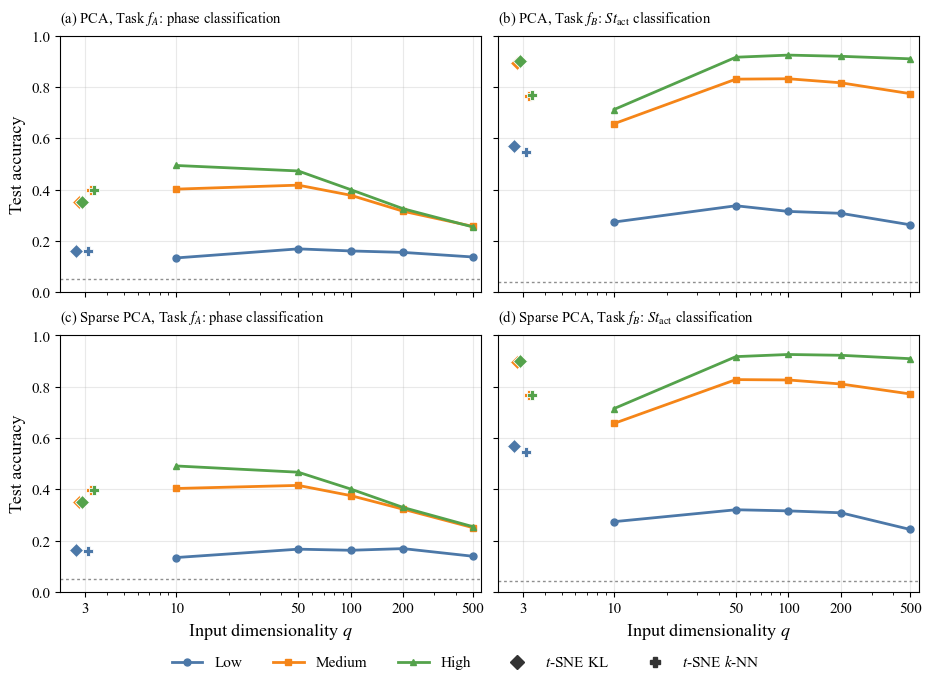

PCA
  Task A: Low: 0.169 at q=50, Medium: 0.418 at q=50, High: 0.494 at q=10
  Task B: Low: 0.337 at q=50, Medium: 0.833 at q=100, High: 0.925 at q=100
Sparse PCA
  Task A: Low: 0.169 at q=200, Medium: 0.415 at q=50, High: 0.491 at q=10
  Task B: Low: 0.320 at q=50, Medium: 0.828 at q=50, High: 0.926 at q=100
Saved PNG: X:\TFG_datos\code\figures\thesis\observed_frequency_prediction_tasks_ab.png
Saved PDF: X:\TFG_datos\code\figures\thesis\observed_frequency_prediction_tasks_ab.pdf


In [2]:
from matplotlib.lines import Line2D

# -----------------------------------------------------------------------------
# Tunable settings for the observed-frequency prediction figure
# -----------------------------------------------------------------------------
OBSERVED_PREDICTION_SETTINGS = {
    "line_dimensions": (10, 50, 100, 200, 500),
    "point_dimensions": (3,),
    "tasks": ("A", "B"),
    "row_methods": ("PCA", "Sparse PCA"),
    "complexities": ("Low", "Medium", "High"),
    "tsne_methods": (r"$t$-SNE KL", r"$t$-SNE $k$-NN"),
    "xscale": "log",
    "ylim": (0.0, 1.0),
    "figsize": (9.2, 6.4),
    "output_stem": "observed_frequency_prediction_tasks_ab",
    "dpi": 300,
    "line_width": 2.0,
    "marker_size": 5.0,
    "tsne_marker_size": 7.0,
    "legend_y": -0.06,
}

# PCA values are from ml_classification_experiment.ipynb.
# Sparse PCA values are from ml_spca_kpca_experiment.ipynb.
OBSERVED_PREDICTION_RESULTS = {
    "PCA": {
        "q": np.array([10, 50, 100, 200, 500], dtype=int),
        "A": {
            "Low": np.array([0.1337, 0.1690, 0.1609, 0.1552, 0.1374]),
            "Medium": np.array([0.4021, 0.4176, 0.3782, 0.3157, 0.2570]),
            "High": np.array([0.4943, 0.4730, 0.4000, 0.3255, 0.2548]),
        },
        "B": {
            "Low": np.array([0.2736, 0.3372, 0.3151, 0.3077, 0.2629]),
            "Medium": np.array([0.6573, 0.8312, 0.8327, 0.8169, 0.7745]),
            "High": np.array([0.7126, 0.9167, 0.9250, 0.9203, 0.9105]),
        },
    },
    "Sparse PCA": {
        "q": np.array([10, 50, 100, 200, 500], dtype=int),
        "A": {
            "Low": np.array([0.1337, 0.1663, 0.1620, 0.1685, 0.1388]),
            "Medium": np.array([0.4031, 0.4151, 0.3753, 0.3222, 0.2506]),
            "High": np.array([0.4909, 0.4666, 0.4009, 0.3289, 0.2545]),
        },
        "B": {
            "Low": np.array([0.2736, 0.3201, 0.3157, 0.3083, 0.2431]),
            "Medium": np.array([0.6570, 0.8279, 0.8264, 0.8108, 0.7718]),
            "High": np.array([0.7149, 0.9175, 0.9259, 0.9227, 0.9095]),
        },
    },
}

# Original out-of-sample t-SNE values from ml_tsne_oos_experiment.ipynb.
OBSERVED_TSNE_POINTS = {
    r"$t$-SNE KL": {
        "q": 3,
        "A": {"Low": 0.1619, "Medium": 0.3519, "High": 0.3506},
        "B": {"Low": 0.5694, "Medium": 0.8949, "High": 0.9002},
    },
    r"$t$-SNE $k$-NN": {
        "q": 3,
        "A": {"Low": 0.1601, "Medium": 0.3991, "High": 0.3970},
        "B": {"Low": 0.5469, "Medium": 0.7670, "High": 0.7675},
    },
}

OBSERVED_COMPLEXITY_STYLE = {
    "Low": {"color": "#4C78A8", "marker": "o"},
    "Medium": {"color": "#F58518", "marker": "s"},
    "High": {"color": "#54A24B", "marker": "^"},
}

OBSERVED_TSNE_STYLE = {
    r"$t$-SNE KL": {"marker": "D", "x_multiplier": 0.92},
    r"$t$-SNE $k$-NN": {"marker": "P", "x_multiplier": 1.08},
}

# Small horizontal offsets avoid overplotting t-SNE points with almost equal values.
OBSERVED_TSNE_COMPLEXITY_X_MULTIPLIER = {
    "Low": 0.96,
    "Medium": 1.00,
    "High": 1.04,
}

OBSERVED_TASK_METADATA = {
    "A": {
        "name": r"Task $f_A$: phase classification",
        "chance": 1.0 / 20.0,
    },
    "B": {
        "name": r"Task $f_B$: $St_{\mathrm{act}}$ classification",
        "chance": 1.0 / 24.0,
    },
}


def plot_observed_prediction_tasks_ab(settings=None):
    """Plot Tasks A and B accuracy for PCA/SPCA and all RF complexities."""
    if settings is None:
        settings = OBSERVED_PREDICTION_SETTINGS

    line_dimensions = np.asarray(settings["line_dimensions"], dtype=int)
    point_dimensions = np.asarray(settings["point_dimensions"], dtype=int)
    row_methods = tuple(settings["row_methods"])
    tasks = tuple(settings["tasks"])
    complexities = tuple(settings["complexities"])
    tsne_methods = tuple(settings["tsne_methods"])

    fig, axes = plt.subplots(
        len(row_methods),
        len(tasks),
        figsize=settings["figsize"],
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    panel_letters = iter("abcdefghijklmnopqrstuvwxyz")

    for row_idx, method in enumerate(row_methods):
        for col_idx, task in enumerate(tasks):
            ax = axes[row_idx, col_idx]
            task_meta = OBSERVED_TASK_METADATA[task]
            result = OBSERVED_PREDICTION_RESULTS[method]
            mask = np.isin(result["q"], line_dimensions)

            # Lines show the selected PCA-based representation for each RF complexity.
            for complexity in complexities:
                style = OBSERVED_COMPLEXITY_STYLE[complexity]
                ax.plot(
                    result["q"][mask],
                    result[task][complexity][mask],
                    color=style["color"],
                    marker=style["marker"],
                    linestyle="-",
                    linewidth=settings["line_width"],
                    markersize=settings["marker_size"],
                )

            # t-SNE points are repeated in both rows to make each row self-contained.
            for tsne_method in tsne_methods:
                tsne = OBSERVED_TSNE_POINTS[tsne_method]
                tsne_style = OBSERVED_TSNE_STYLE[tsne_method]
                for complexity in complexities:
                    complexity_style = OBSERVED_COMPLEXITY_STYLE[complexity]
                    x_plot = (
                        tsne["q"]
                        * tsne_style["x_multiplier"]
                        * OBSERVED_TSNE_COMPLEXITY_X_MULTIPLIER[complexity]
                    )
                    ax.plot(
                        x_plot,
                        tsne[task][complexity],
                        color=complexity_style["color"],
                        marker=tsne_style["marker"],
                        linestyle="None",
                        markersize=settings["tsne_marker_size"],
                        markeredgecolor="white",
                        markeredgewidth=0.6,
                    )

            ax.axhline(
                task_meta["chance"],
                color="0.45",
                linestyle=(0, (2, 2)),
                linewidth=1.0,
                alpha=0.8,
            )

            panel_label = f"({next(panel_letters)}) {method}, {task_meta['name']}"
            ax.text(
                0.0,
                1.035,
                panel_label,
                transform=ax.transAxes,
                ha="left",
                va="bottom",
                fontsize=10.5,
                clip_on=False,
            )

            ax.set_xscale(settings["xscale"])
            xticks = np.unique(np.r_[point_dimensions, line_dimensions])
            ax.set_xticks(xticks)
            ax.set_xticklabels([str(q) for q in xticks])
            if settings["xscale"] == "log":
                ax.set_xlim(float(np.min(xticks)) * 0.72, float(np.max(xticks)) * 1.12)
            else:
                ax.set_xlim(0, max(line_dimensions) + 25)
            ax.set_ylim(*settings["ylim"])
            ax.grid(True, alpha=0.28)

            if col_idx == 0:
                ax.set_ylabel("Test accuracy")
            if row_idx == len(row_methods) - 1:
                ax.set_xlabel(r"Input dimensionality $q$")

    complexity_handles = [
        Line2D(
            [0],
            [0],
            color=OBSERVED_COMPLEXITY_STYLE[complexity]["color"],
            marker=OBSERVED_COMPLEXITY_STYLE[complexity]["marker"],
            linestyle="-",
            linewidth=settings["line_width"],
            markersize=settings["marker_size"],
            label=complexity,
        )
        for complexity in complexities
    ]

    tsne_handles = [
        Line2D(
            [0],
            [0],
            color="0.20",
            marker=OBSERVED_TSNE_STYLE[tsne_method]["marker"],
            linestyle="None",
            markersize=settings["tsne_marker_size"],
            label=tsne_method,
        )
        for tsne_method in tsne_methods
    ]

    fig.legend(
        complexity_handles + tsne_handles,
        [handle.get_label() for handle in complexity_handles + tsne_handles],
        loc="lower center",
        ncol=5,
        frameon=False,
        bbox_to_anchor=(0.5, settings["legend_y"]),
    )

    png_path = FIGURE_DIR / f"{settings['output_stem']}.png"
    pdf_path = FIGURE_DIR / f"{settings['output_stem']}.pdf"
    fig.savefig(png_path, dpi=settings["dpi"], bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    summary = {"png_path": png_path, "pdf_path": pdf_path, "best_values": {}}
    for method in row_methods:
        summary["best_values"][method] = {}
        for task in tasks:
            summary["best_values"][method][task] = {}
            for complexity in complexities:
                result = OBSERVED_PREDICTION_RESULTS[method]
                idx = int(np.argmax(result[task][complexity]))
                summary["best_values"][method][task][complexity] = {
                    "q": int(result["q"][idx]),
                    "accuracy": float(result[task][complexity][idx]),
                }
    return summary


observed_prediction_summary = plot_observed_prediction_tasks_ab()

for method, method_values in observed_prediction_summary["best_values"].items():
    print(method)
    for task, task_values in method_values.items():
        formatted = ", ".join(
            f"{complexity}: {value['accuracy']:.3f} at q={value['q']}"
            for complexity, value in task_values.items()
        )
        print(f"  Task {task}: {formatted}")

print(f"Saved PNG: {observed_prediction_summary['png_path']}")
print(f"Saved PDF: {observed_prediction_summary['pdf_path']}")


The separated layout shows that PCA and Sparse PCA have almost the same predictive behaviour across all Random Forest complexity levels. For phase classification, the highest accuracies are obtained with high-complexity models and small input dimension, especially \(q=10\); increasing the number of retained coordinates reduces the accuracy. This supports the interpretation that the most phase-relevant information is concentrated in the leading coordinates. For \(St_{\mathrm{act}}\) classification, increasing the model complexity has a stronger effect, and the best results occur once the representation contains at least \(q=50\) coordinates. The original out-of-sample \(t\)-SNE points show competitive performance for \(St_{\mathrm{act}}\) with KL optimization, but they remain below the best PCA and Sparse PCA curves for phase classification.

## Prediction on Held-Out Actuation Frequencies

The leave-frequencies-out experiment evaluates whether the reduced coordinates generalize to actuation frequencies that were not used during training. Task \(f_D\) is treated as a regression problem for \(St_{\mathrm{act}}\), so the plotted metric is \(R^2\). Task \(f_E\) is phase-transfer classification, so the plotted metric is accuracy. The figure separates PCA and Sparse PCA into different rows, while the three Random Forest complexity levels are shown as separate curves. The original three-dimensional out-of-sample \(t\)-SNE results are included as points at \(q=3\) in both rows.


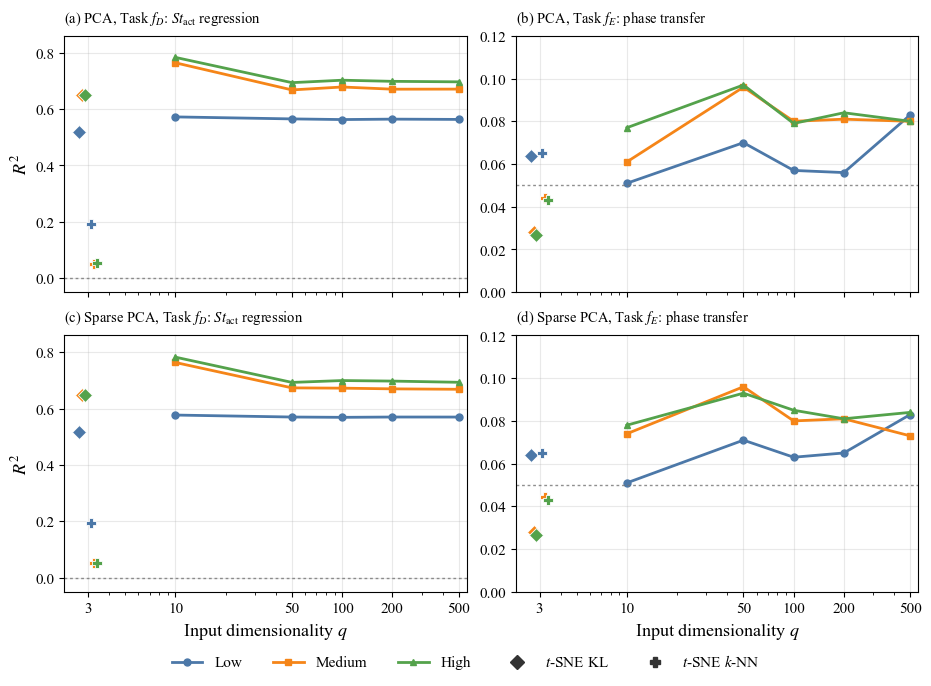

PCA
  Task D: Low: 0.572 at q=10, Medium: 0.764 at q=10, High: 0.784 at q=10
  Task E: Low: 0.083 at q=500, Medium: 0.096 at q=50, High: 0.097 at q=50
Sparse PCA
  Task D: Low: 0.578 at q=10, Medium: 0.764 at q=10, High: 0.783 at q=10
  Task E: Low: 0.083 at q=500, Medium: 0.096 at q=50, High: 0.093 at q=50
Saved PNG: X:\TFG_datos\code\figures\thesis\unseen_frequency_prediction_tasks_de.png
Saved PDF: X:\TFG_datos\code\figures\thesis\unseen_frequency_prediction_tasks_de.pdf


In [2]:
from matplotlib.lines import Line2D

# -----------------------------------------------------------------------------
# Tunable settings for the held-out-frequency prediction figure
# -----------------------------------------------------------------------------
GENERALIZATION_PREDICTION_SETTINGS = {
    "line_dimensions": (10, 50, 100, 200, 500),
    "point_dimensions": (3,),
    "tasks": ("D", "E"),
    "row_methods": ("PCA", "Sparse PCA"),
    "complexities": ("Low", "Medium", "High"),
    "tsne_methods": (r"$t$-SNE KL", r"$t$-SNE $k$-NN"),
    "xscale": "log",
    "figsize": (9.2, 6.4),
    "output_stem": "unseen_frequency_prediction_tasks_de",
    "dpi": 300,
    "line_width": 2.0,
    "marker_size": 5.0,
    "tsne_marker_size": 7.0,
    "legend_y": -0.06,
}

# PCA values are from ml_classification_experiment.ipynb.
# Sparse PCA values are from ml_spca_kpca_experiment.ipynb.
GENERALIZATION_PREDICTION_RESULTS = {
    "PCA": {
        "q": np.array([10, 50, 100, 200, 500], dtype=int),
        "D": {
            "Low": np.array([0.5723, 0.5652, 0.5629, 0.5644, 0.5634]),
            "Medium": np.array([0.7644, 0.6681, 0.6785, 0.6707, 0.6710]),
            "High": np.array([0.7836, 0.6939, 0.7026, 0.6986, 0.6968]),
        },
        "E": {
            "Low": np.array([0.051, 0.070, 0.057, 0.056, 0.083]),
            "Medium": np.array([0.061, 0.096, 0.080, 0.081, 0.080]),
            "High": np.array([0.077, 0.097, 0.079, 0.084, 0.080]),
        },
    },
    "Sparse PCA": {
        "q": np.array([10, 50, 100, 200, 500], dtype=int),
        "D": {
            "Low": np.array([0.5775, 0.5705, 0.5694, 0.5705, 0.5704]),
            "Medium": np.array([0.7641, 0.6740, 0.6730, 0.6705, 0.6690]),
            "High": np.array([0.7831, 0.6934, 0.7000, 0.6981, 0.6938]),
        },
        "E": {
            "Low": np.array([0.051, 0.071, 0.063, 0.065, 0.083]),
            "Medium": np.array([0.074, 0.096, 0.080, 0.081, 0.073]),
            "High": np.array([0.078, 0.093, 0.085, 0.081, 0.084]),
        },
    },
}

# Original out-of-sample t-SNE values from ml_tsne_oos_experiment.ipynb.
GENERALIZATION_TSNE_POINTS = {
    r"$t$-SNE KL": {
        "q": 3,
        "D": {"Low": 0.5189, "Medium": 0.6494, "High": 0.6499},
        "E": {"Low": 0.0639, "Medium": 0.0280, "High": 0.0267},
    },
    r"$t$-SNE $k$-NN": {
        "q": 3,
        "D": {"Low": 0.1927, "Medium": 0.0510, "High": 0.0521},
        "E": {"Low": 0.0651, "Medium": 0.0442, "High": 0.0432},
    },
}

GENERALIZATION_COMPLEXITY_STYLE = {
    "Low": {"color": "#4C78A8", "marker": "o"},
    "Medium": {"color": "#F58518", "marker": "s"},
    "High": {"color": "#54A24B", "marker": "^"},
}

GENERALIZATION_TSNE_STYLE = {
    r"$t$-SNE KL": {"marker": "D", "x_multiplier": 0.92},
    r"$t$-SNE $k$-NN": {"marker": "P", "x_multiplier": 1.08},
}

GENERALIZATION_TSNE_COMPLEXITY_X_MULTIPLIER = {
    "Low": 0.96,
    "Medium": 1.00,
    "High": 1.04,
}

GENERALIZATION_TASK_METADATA = {
    "D": {
        "name": r"Task $f_D$: $St_{\mathrm{act}}$ regression",
        "ylabel": r"$R^2$",
        "ylim": (-0.05, 0.86),
        "baseline": 0.0,
    },
    "E": {
        "name": r"Task $f_E$: phase transfer",
        "ylabel": "Accuracy",
        "ylim": (0.0, 0.12),
        "baseline": 1.0 / 20.0,
    },
}


def plot_generalization_prediction_tasks_de(settings=None):
    """Plot held-out-frequency regression and phase-transfer performance."""
    if settings is None:
        settings = GENERALIZATION_PREDICTION_SETTINGS

    line_dimensions = np.asarray(settings["line_dimensions"], dtype=int)
    point_dimensions = np.asarray(settings["point_dimensions"], dtype=int)
    row_methods = tuple(settings["row_methods"])
    tasks = tuple(settings["tasks"])
    complexities = tuple(settings["complexities"])
    tsne_methods = tuple(settings["tsne_methods"])

    fig, axes = plt.subplots(
        len(row_methods),
        len(tasks),
        figsize=settings["figsize"],
        sharex=True,
        constrained_layout=True,
    )

    panel_letters = iter("abcdefghijklmnopqrstuvwxyz")

    for row_idx, method in enumerate(row_methods):
        for col_idx, task in enumerate(tasks):
            ax = axes[row_idx, col_idx]
            task_meta = GENERALIZATION_TASK_METADATA[task]
            result = GENERALIZATION_PREDICTION_RESULTS[method]
            mask = np.isin(result["q"], line_dimensions)

            for complexity in complexities:
                style = GENERALIZATION_COMPLEXITY_STYLE[complexity]
                ax.plot(
                    result["q"][mask],
                    result[task][complexity][mask],
                    color=style["color"],
                    marker=style["marker"],
                    linestyle="-",
                    linewidth=settings["line_width"],
                    markersize=settings["marker_size"],
                )

            for tsne_method in tsne_methods:
                tsne = GENERALIZATION_TSNE_POINTS[tsne_method]
                tsne_style = GENERALIZATION_TSNE_STYLE[tsne_method]
                for complexity in complexities:
                    complexity_style = GENERALIZATION_COMPLEXITY_STYLE[complexity]
                    x_plot = (
                        tsne["q"]
                        * tsne_style["x_multiplier"]
                        * GENERALIZATION_TSNE_COMPLEXITY_X_MULTIPLIER[complexity]
                    )
                    ax.plot(
                        x_plot,
                        tsne[task][complexity],
                        color=complexity_style["color"],
                        marker=tsne_style["marker"],
                        linestyle="None",
                        markersize=settings["tsne_marker_size"],
                        markeredgecolor="white",
                        markeredgewidth=0.6,
                    )

            ax.axhline(
                task_meta["baseline"],
                color="0.45",
                linestyle=(0, (2, 2)),
                linewidth=1.0,
                alpha=0.8,
            )

            panel_label = f"({next(panel_letters)}) {method}, {task_meta['name']}"
            ax.text(
                0.0,
                1.035,
                panel_label,
                transform=ax.transAxes,
                ha="left",
                va="bottom",
                fontsize=10.5,
                clip_on=False,
            )

            ax.set_xscale(settings["xscale"])
            xticks = np.unique(np.r_[point_dimensions, line_dimensions])
            ax.set_xticks(xticks)
            ax.set_xticklabels([str(q) for q in xticks])
            if settings["xscale"] == "log":
                ax.set_xlim(float(np.min(xticks)) * 0.72, float(np.max(xticks)) * 1.12)
            else:
                ax.set_xlim(0, max(line_dimensions) + 25)
            ax.set_ylim(*task_meta["ylim"])
            ax.grid(True, alpha=0.28)

            if col_idx == 0:
                ax.set_ylabel(task_meta["ylabel"])
            if row_idx == len(row_methods) - 1:
                ax.set_xlabel(r"Input dimensionality $q$")

    complexity_handles = [
        Line2D(
            [0],
            [0],
            color=GENERALIZATION_COMPLEXITY_STYLE[complexity]["color"],
            marker=GENERALIZATION_COMPLEXITY_STYLE[complexity]["marker"],
            linestyle="-",
            linewidth=settings["line_width"],
            markersize=settings["marker_size"],
            label=complexity,
        )
        for complexity in complexities
    ]

    tsne_handles = [
        Line2D(
            [0],
            [0],
            color="0.20",
            marker=GENERALIZATION_TSNE_STYLE[tsne_method]["marker"],
            linestyle="None",
            markersize=settings["tsne_marker_size"],
            label=tsne_method,
        )
        for tsne_method in tsne_methods
    ]

    fig.legend(
        complexity_handles + tsne_handles,
        [handle.get_label() for handle in complexity_handles + tsne_handles],
        loc="lower center",
        ncol=5,
        frameon=False,
        bbox_to_anchor=(0.5, settings["legend_y"]),
    )

    png_path = FIGURE_DIR / f"{settings['output_stem']}.png"
    pdf_path = FIGURE_DIR / f"{settings['output_stem']}.pdf"
    fig.savefig(png_path, dpi=settings["dpi"], bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    summary = {"png_path": png_path, "pdf_path": pdf_path, "best_values": {}}
    for method in row_methods:
        summary["best_values"][method] = {}
        for task in tasks:
            summary["best_values"][method][task] = {}
            for complexity in complexities:
                result = GENERALIZATION_PREDICTION_RESULTS[method]
                idx = int(np.argmax(result[task][complexity]))
                summary["best_values"][method][task][complexity] = {
                    "q": int(result["q"][idx]),
                    "value": float(result[task][complexity][idx]),
                }
    return summary


generalization_prediction_summary = plot_generalization_prediction_tasks_de()

for method, method_values in generalization_prediction_summary["best_values"].items():
    print(method)
    for task, task_values in method_values.items():
        formatted = ", ".join(
            f"{complexity}: {value['value']:.3f} at q={value['q']}"
            for complexity, value in task_values.items()
        )
        print(f"  Task {task}: {formatted}")

print(f"Saved PNG: {generalization_prediction_summary['png_path']}")
print(f"Saved PDF: {generalization_prediction_summary['pdf_path']}")


The held-out-frequency results show a clear contrast between the two generalization tasks. For \(St_{\mathrm{act}}\) regression, PCA and Sparse PCA both reach their largest \(R^2\) values with \(q=10\), and the medium- and high-complexity models perform substantially better than the low-complexity model. This indicates that the leading coordinates already contain the smooth frequency ordering needed for interpolation across unseen actuation values. Phase transfer is much weaker: all accuracies remain close to the chance level of \(1/20=0.05\), even when model complexity and input dimension increase. The \(t\)-SNE KL projection retains part of the frequency ordering, but neither \(t\)-SNE variant gives reliable phase transfer to unseen frequencies.